
================ Correlation Results ================

                        Relationship  Pearson_r  Pearson_p  Spearman_rho  Spearman_p   Slope  Intercept     R2
    Molar volume vs Mean total force    -0.6201     0.0180       -0.5516      0.0408 -0.0020     0.7380 0.3845
Onsager polarity vs Mean total force     0.7259     0.0033        0.5868      0.0274  0.2973     0.3414 0.5270
            Viscosity vs TAMSD alpha    -0.5648     0.0354       -0.4725      0.0880 -0.1888     0.8963 0.3190
      Surface tension vs TAMSD alpha    -0.3861     0.1727       -0.1956      0.5028 -0.0166     1.1706 0.1491

================ Molar Volume ================

            solvent       MW  density  Vm_mL_mol  Vm_A3_molecule
               CPME 100.1589   0.8620   116.1936        192.9440
                DMC  90.0779   1.0690    84.2637        139.9232
            acetone  58.0791   0.7845    74.0333        122.9351
       acetonitrile  41.0519   0.7769    52.8406         87.7440
        cyclohe

KeyboardInterrupt: 

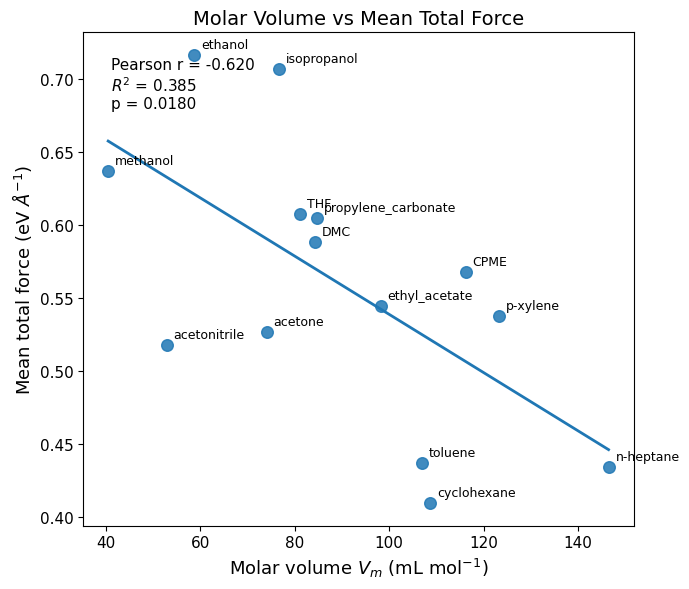

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress


# ============================================================
# 1. 输入你的实验/模拟数据
# ============================================================

data = {
    "solvent": [
        "CPME", "DMC", "acetone", "acetonitrile", "cyclohexane",
        "ethanol", "ethyl_acetate", "isopropanol", "methanol",
        "n-heptane", "p-xylene", "propylene_carbonate", "THF", "toluene"
    ],

    # molecular weight, g/mol
    "MW": [
        100.1589, 90.0779, 58.0791, 41.0519, 84.1595,
        46.0684, 88.1051, 60.0950, 32.0419,
        100.2019, 106.1650, 102.0886, 72.1057, 92.1384
    ],

    # Onsager polarity
    "Onsager": [
        0.7148, 0.5818, 0.9285, 0.9585, 0.4039,
        0.9408, 0.7688, 0.9241, 0.9547,
        0.3779, 0.4586, 0.9769, 0.8107, 0.4781
    ],

    # Mean total force, eV/A
    "Mean_total_force": [
        0.5675, 0.5885, 0.5265, 0.5174, 0.4093,
        0.7165, 0.5447, 0.7067, 0.6371,
        0.4341, 0.5378, 0.6049, 0.6075, 0.4368
    ],

    # TAMSD alpha
    "alpha": [
        1.1050, 1.0305, 0.8760, 0.8608, 0.6273,
        0.8601, 0.5924, 0.4635, 0.6732,
        0.9057, 0.4065, 0.4251, 0.6940, 0.8920
    ],

    # --------------------------------------------------------
    # Density at approximately 25 °C, g/mL
    # 请根据你最终论文采用的温度/文献值修改
    # --------------------------------------------------------
    "density": [
        0.862,   # CPME
        1.069,   # DMC
        0.7845,  # acetone
        0.7769,  # acetonitrile
        0.7739,  # cyclohexane
        0.7850,  # ethanol
        0.8970,  # ethyl acetate
        0.7850,  # isopropanol
        0.7920,  # methanol
        0.6840,  # n-heptane
        0.8610,  # p-xylene
        1.2040,  # propylene carbonate
        0.8890,  # THF
        0.8620   # toluene
    ],

    # --------------------------------------------------------
    # Dynamic viscosity at approximately 25 °C, mPa·s
    # --------------------------------------------------------
    "viscosity": [
        0.58,   # CPME
        0.59,   # DMC
        0.306,  # acetone
        0.345,  # acetonitrile
        0.894,  # cyclohexane
        1.074,  # ethanol
        0.426,  # ethyl acetate
        2.04,   # isopropanol
        0.544,  # methanol
        0.387,  # n-heptane
        0.609,  # p-xylene
        2.53,   # propylene carbonate
        0.46,   # THF
        0.53    # toluene
    ],

    # --------------------------------------------------------
    # Surface tension at approximately 25 °C, mN/m
    # --------------------------------------------------------
    "surface_tension": [
        23.5,  # CPME
        25.7,  # DMC
        23.3,  # acetone
        28.7,  # acetonitrile
        25.2,  # cyclohexane
        21.97, # ethanol
        23.9,  # ethyl acetate
        21.7,  # isopropanol
        22.1,  # methanol
        20.1,  # n-heptane
        28.2,  # p-xylene
        41.1,  # propylene carbonate
        26.4,  # THF
        28.4   # toluene
    ]
}


df = pd.DataFrame(data)


# ============================================================
# 2. 计算摩尔体积
#
# MW [g/mol] / density [g/mL]
# = mL/mol
#
# 再转换为 Å^3/molecule
# ============================================================

df["Vm_mL_mol"] = df["MW"] / df["density"]

# 1 mL = 1e24 Å^3
# 1 mol = 6.02214076e23 molecules
# 因此：
# 1 mL/mol ≈ 1.66054 Å^3/molecule

NA = 6.02214076e23

df["Vm_A3_molecule"] = (
    df["Vm_mL_mol"] * 1e-6 / NA / 1e-30
)


# ============================================================
# 3. 定义统计函数
# ============================================================

def correlation_analysis(x, y):

    # Pearson
    pearson_r, pearson_p = pearsonr(x, y)

    # Spearman
    spearman_rho, spearman_p = spearmanr(x, y)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    R2 = r_value ** 2

    return {
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_rho": spearman_rho,
        "Spearman_p": spearman_p,
        "Slope": slope,
        "Intercept": intercept,
        "R2": R2
    }


# ============================================================
# 4. 四组关系
# ============================================================

results = []


# ------------------------------------------------------------
# Relationship 1:
# Molar volume vs Mean total force
# ------------------------------------------------------------

res1 = correlation_analysis(
    df["Vm_mL_mol"],
    df["Mean_total_force"]
)

res1["Relationship"] = "Molar volume vs Mean total force"
results.append(res1)


# ------------------------------------------------------------
# Relationship 2:
# Onsager polarity vs Mean total force
# ------------------------------------------------------------

res2 = correlation_analysis(
    df["Onsager"],
    df["Mean_total_force"]
)

res2["Relationship"] = "Onsager polarity vs Mean total force"
results.append(res2)


# ------------------------------------------------------------
# Relationship 3:
# Viscosity vs TAMSD alpha
# ------------------------------------------------------------

res3 = correlation_analysis(
    df["viscosity"],
    df["alpha"]
)

res3["Relationship"] = "Viscosity vs TAMSD alpha"
results.append(res3)


# ------------------------------------------------------------
# Relationship 4:
# Surface tension vs TAMSD alpha
# ------------------------------------------------------------

res4 = correlation_analysis(
    df["surface_tension"],
    df["alpha"]
)

res4["Relationship"] = "Surface tension vs TAMSD alpha"
results.append(res4)


# ============================================================
# 5. 输出统计结果
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Relationship",
        "Pearson_r",
        "Pearson_p",
        "Spearman_rho",
        "Spearman_p",
        "Slope",
        "Intercept",
        "R2"
    ]
]

print("\n================ Correlation Results ================\n")

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 6. 输出摩尔体积
# ============================================================

print("\n================ Molar Volume ================\n")

print(
    df[
        [
            "solvent",
            "MW",
            "density",
            "Vm_mL_mol",
            "Vm_A3_molecule"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 7. 绘制散点 + 线性拟合
# ============================================================

def plot_relationship(
    x,
    y,
    xlabel,
    ylabel,
    title,
    filename
):

    fig, ax = plt.subplots(figsize=(7, 6))

    # scatter
    ax.scatter(
        x,
        y,
        s=70,
        alpha=0.85
    )

    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(
        np.min(x),
        np.max(x),
        200
    )

    y_fit = slope * x_fit + intercept

    ax.plot(
        x_fit,
        y_fit,
        linewidth=2
    )

    # solvent labels
    for i, name in enumerate(df["solvent"]):

        ax.annotate(
            name,
            (x.iloc[i], y.iloc[i]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    # correlation information
    ax.text(
        0.05,
        0.95,
        f"Pearson r = {r_value:.3f}\n"
        f"$R^2$ = {r_value**2:.3f}\n"
        f"p = {p_value:.4f}",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=11
    )

    ax.set_xlabel(
        xlabel,
        fontsize=13
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13
    )

    ax.set_title(
        title,
        fontsize=14
    )

    ax.tick_params(
        labelsize=11
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# Figure 1
# ============================================================

plot_relationship(
    df["Vm_mL_mol"],
    df["Mean_total_force"],
    r"Molar volume $V_m$ (mL mol$^{-1}$)",
    r"Mean total force (eV $\AA^{-1}$)",
    "Molar Volume vs Mean Total Force",
    "Figure_Vm_vs_Force.png"
)


# ============================================================
# Figure 2
# ============================================================

plot_relationship(
    df["Onsager"],
    df["Mean_total_force"],
    r"Onsager polarity $f(\varepsilon)$",
    r"Mean total force (eV $\AA^{-1}$)",
    "Onsager Polarity vs Mean Total Force",
    "Figure_Onsager_vs_Force.png"
)


# ============================================================
# Figure 3
# ============================================================

plot_relationship(
    df["viscosity"],
    df["alpha"],
    r"Viscosity $\eta$ (mPa s)",
    r"TAMSD exponent $\alpha$",
    "Viscosity vs TAMSD Exponent",
    "Figure_Viscosity_vs_Alpha.png"
)


# ============================================================
# Figure 4
# ============================================================

plot_relationship(
    df["surface_tension"],
    df["alpha"],
    r"Surface tension $\gamma$ (mN m$^{-1}$)",
    r"TAMSD exponent $\alpha$",
    "Surface Tension vs TAMSD Exponent",
    "Figure_SurfaceTension_vs_Alpha.png"
)


# ============================================================
# 8. 保存全部结果
# ============================================================

df.to_csv(
    "solvent_physical_properties.csv",
    index=False
)

results_df.to_csv(
    "correlation_results.csv",
    index=False
)

print("\nAnalysis finished.")
print("Saved:")
print("  solvent_physical_properties.csv")
print("  correlation_results.csv")
print("  Figure_Vm_vs_Force.png")
print("  Figure_Onsager_vs_Force.png")
print("  Figure_Viscosity_vs_Alpha.png")
print("  Figure_SurfaceTension_vs_Alpha.png")



MODEL COMPARISON
Model       R2  Adjusted_R2     RMSE        AIC
   F5 0.527050     0.385165 0.062194 -71.770026
   F1 0.526984     0.440981 0.062198 -73.768069
   D1 0.477953     0.383035 0.251320 -34.668796
   F3 0.363652     0.247953 0.072142 -69.615443
   F2 0.266127     0.132696 0.077473 -67.619174
   D2 0.171410     0.020758 0.195139 -41.753146
   F4 0.011397    -0.168349 0.089919 -63.447777


FITTED PARAMETERS

F5
Equation:
F = F0 + A*f + B/Vm
Parameter 1: 0.34168782
Parameter 2: 0.30076162
Parameter 3: -0.22518345

F1
Equation:
F = F0 + A*f
Parameter 1: 0.34138535
Parameter 2: 0.29732198

D1
Equation:
Kα = A*(ηRh)^(-n)
Parameter 1: 0.61301388
Parameter 2: 0.35577406

F3
Equation:
F = F0 + A*f/Vm
Parameter 1: 0.4684786
Parameter 2: 9.1518672

F2
Equation:
F = F0 + A/Vm
Parameter 1: 0.43487647
Parameter 2: 9.9375308

D2
Equation:
alpha = A - B*F/(6*pi*eta*Rh)
Parameter 1: 0.56199681
Parameter 2: -0.00057977379

F4
Equation:
F = F0 + A*mu^2/Vm^(4/3)
Parameter 1: 0.55313111
Param

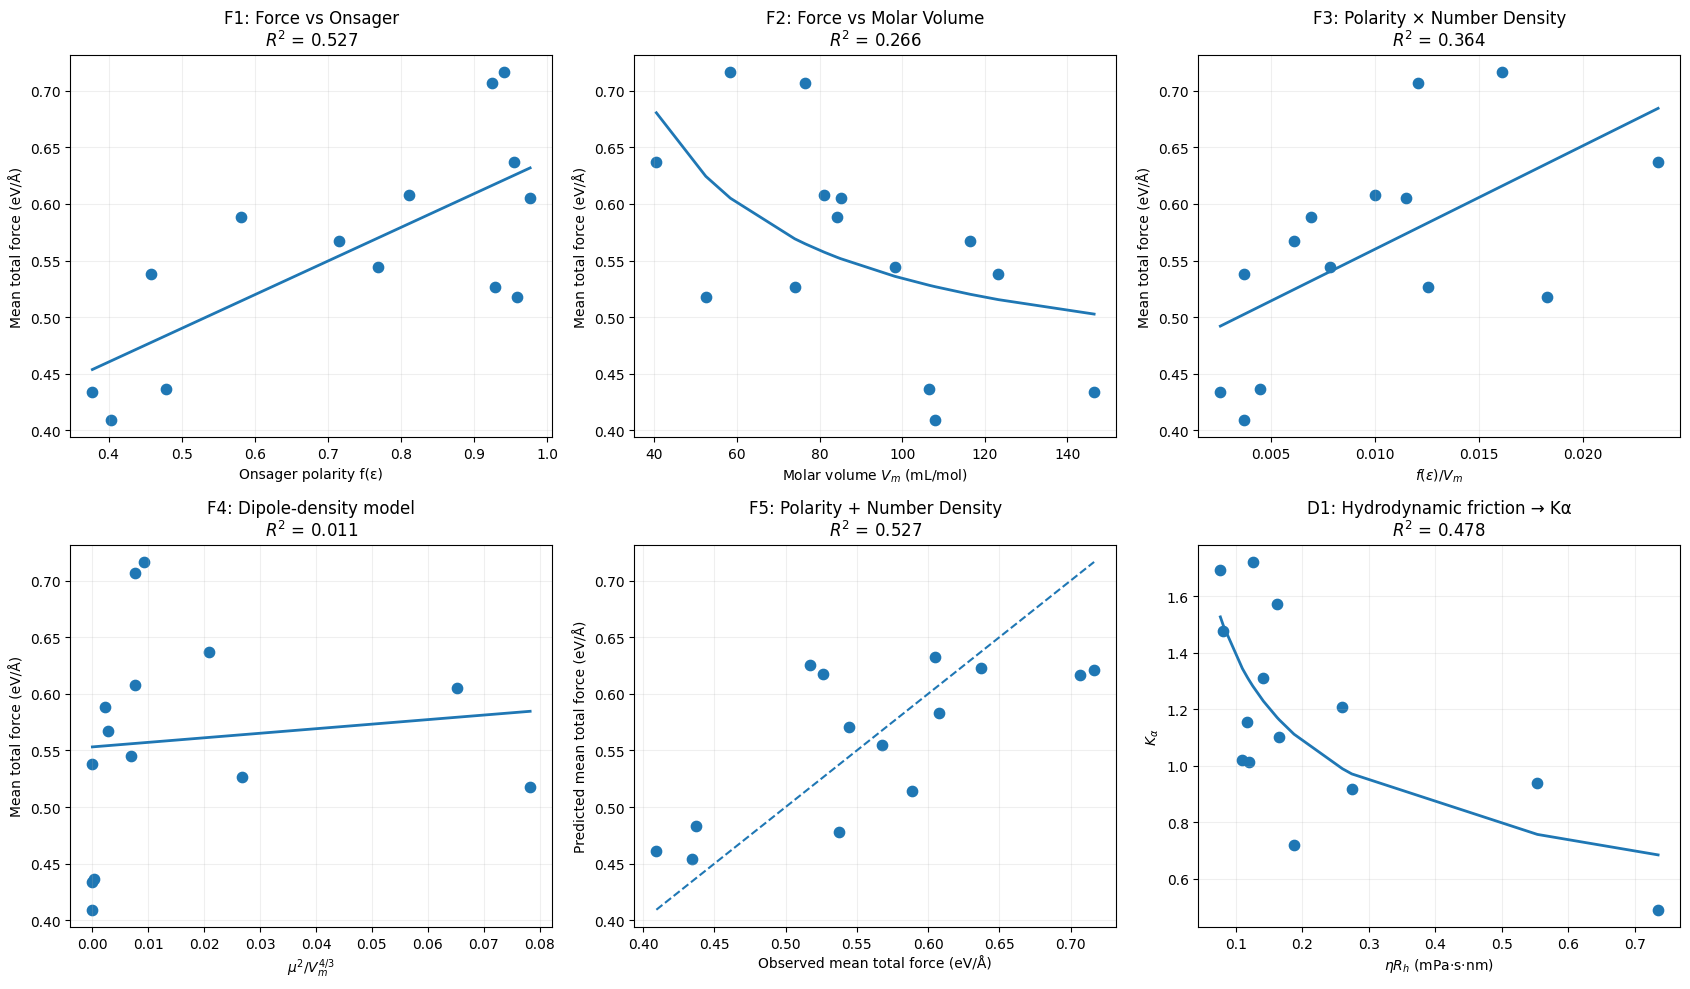

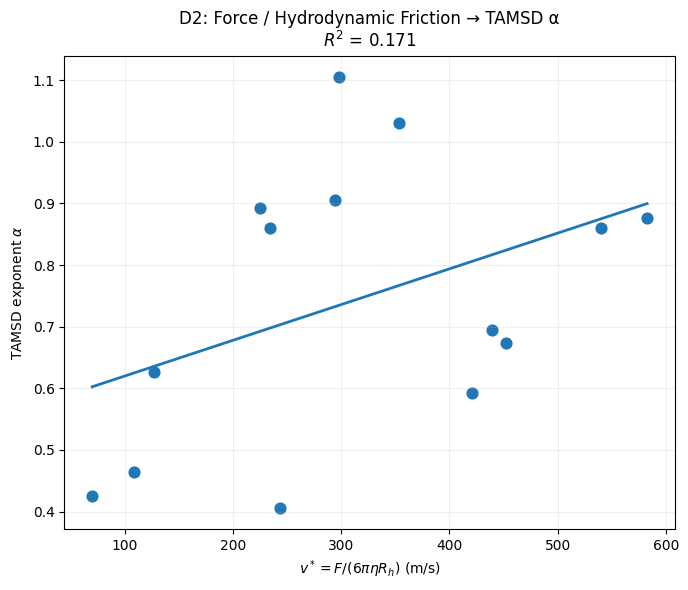



CALCULATED MOLAR VOLUME
            solvent       MW  density         Vm  viscosity  surface_tension   Rh
               CPME 100.1589   0.8600 116.463837      0.600            24.50 0.27
                DMC  90.0779   1.0700  84.184953      0.590            28.50 0.24
            acetone  58.0791   0.7850  73.986115      0.320            23.50 0.24
       acetonitrile  41.0519   0.7830  52.428991      0.370            28.50 0.22
        cyclohexane  84.1595   0.7790 108.035302      0.980            25.25 0.28
            ethanol  46.0684   0.7890  58.388340      1.085            22.05 0.24
      ethyl_acetate  88.1051   0.8970  98.221962      0.440            23.75 0.25
        isopropanol  60.0950   0.7850  76.554140      2.050            21.35 0.27
           methanol  32.0419   0.7920  40.456944      0.570            22.35 0.21
          n-heptane 100.2019   0.6840 146.494006      0.405            20.25 0.31
           p-xylene 106.1650   0.8610 123.304297      0.625            2

In [ ]:
# ============================================================
# Solvent properties -> Mean Force / TAMSD
# Six physics-based models
#
# Models:
#
# F1:  F = F0 + A*f(Onsager)
#
# F2:  F = F0 + A/Vm
#
# F3:  F = F0 + A*f(Onsager)/Vm
#
# F4:  F = F0 + A*mu^2/Vm^(4/3)
#
# F5:  F = F0 + A*f(Onsager) + B/Vm
#
# D1:  Kalpha = A*(eta*Rh)^(-n)
#
# D2:  alpha = A - B*F/(6*pi*eta*Rh)
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# 1. DATA
# ============================================================

data = {

    "solvent": [
        "CPME",
        "DMC",
        "acetone",
        "acetonitrile",
        "cyclohexane",
        "ethanol",
        "ethyl_acetate",
        "isopropanol",
        "methanol",
        "n-heptane",
        "p-xylene",
        "propylene_carbonate",
        "THF",
        "toluene"
    ],

    # ---------- Molecular weight ----------
    "MW": [
        100.1589,
        90.0779,
        58.0791,
        41.0519,
        84.1595,
        46.0684,
        88.1051,
        60.095,
        32.0419,
        100.2019,
        106.165,
        102.0886,
        72.1057,
        92.1384
    ],

    # ---------- Onsager polarity ----------
    "Onsager": [
        0.7148,
        0.5818,
        0.9285,
        0.9585,
        0.4039,
        0.9408,
        0.7688,
        0.9241,
        0.9547,
        0.3779,
        0.4586,
        0.9769,
        0.8107,
        0.4781
    ],

    # ---------- Dipole moment, D ----------
    "dipole": [
        1.27,
        0.91,
        2.88,
        3.92,
        0.0,
        1.44,
        1.78,
        1.58,
        1.70,
        0.0,
        0.0,
        4.94,
        1.63,
        0.33
    ],

    # ---------- Mean total force, eV/A ----------
    "F_total": [
        0.5675,
        0.5885,
        0.5265,
        0.5174,
        0.4093,
        0.7165,
        0.5447,
        0.7067,
        0.6371,
        0.4341,
        0.5378,
        0.6049,
        0.6075,
        0.4368
    ],

    # ---------- TAMSD alpha ----------
    "alpha": [
        1.1050,
        1.0305,
        0.8760,
        0.8608,
        0.6273,
        0.8601,
        0.5924,
        0.4635,
        0.6732,
        0.9057,
        0.4065,
        0.4251,
        0.6940,
        0.8920
    ],

    # ---------- TAMSD K_alpha ----------
    "Kalpha": [
        1.5731,
        1.3101,
        1.6939,
        1.4791,
        0.9189,
        1.2076,
        1.0197,
        0.9390,
        1.0149,
        1.7225,
        0.7182,
        0.4896,
        1.1545,
        1.1009
    ],

    # ========================================================
    # viscosity
    # midpoint of your given range
    # unit = mPa.s = cP
    # ========================================================

    "viscosity": [
        0.60,        # CPME
        0.59,        # DMC
        0.32,        # acetone
        0.37,        # acetonitrile
        0.98,        # cyclohexane
        1.085,       # ethanol
        0.44,        # ethyl acetate
        2.05,        # isopropanol
        0.57,        # methanol
        0.405,       # n-heptane
        0.625,       # p-xylene
        2.45,        # propylene carbonate
        0.47,        # THF
        0.57         # toluene
    ],

    # ========================================================
    # density
    # unit = g/mL
    # ========================================================

    "density": [
        0.860,       # CPME
        1.070,
        0.785,
        0.783,
        0.779,
        0.789,
        0.897,
        0.785,
        0.792,
        0.684,
        0.861,
        1.200,
        0.889,
        0.8645        # midpoint 0.862-0.867
    ],

    # ========================================================
    # surface tension
    # midpoint of your given ranges
    # unit = mN/m
    # ========================================================

    "surface_tension": [
        24.5,
        28.5,
        23.5,
        28.5,
        25.25,
        22.05,
        23.75,
        21.35,
        22.35,
        20.25,
        28.5,
        41.5,
        26.25,
        28.1
    ],

    # ========================================================
    # estimated molecular equivalent radius
    # unit = nm
    # ========================================================

    "Rh": [
        0.27,
        0.24,
        0.24,
        0.22,
        0.28,
        0.24,
        0.25,
        0.27,
        0.21,
        0.31,
        0.30,
        0.30,
        0.25,
        0.29
    ]
}


df = pd.DataFrame(data)


# ============================================================
# 2. CALCULATE MOLAR VOLUME
#
# Vm = MW / density
#
# MW: g/mol
# density: g/mL
#
# Vm: mL/mol
#
# ============================================================

df["Vm"] = df["MW"] / df["density"]


# ============================================================
# 3. CREATE PHYSICAL COMPOSITE VARIABLES
# ============================================================

# molecular number density proxy
df["number_density_proxy"] = 1.0 / df["Vm"]

# hydrodynamic friction proxy
#
# eta * Rh
#
# eta = mPa.s
# Rh = nm
#
df["eta_Rh"] = df["viscosity"] * df["Rh"]

# More physically dimensioned version for velocity:
#
# eta: mPa.s -> Pa.s
# Rh: nm -> m
#
eta_SI = df["viscosity"].values * 1e-3
Rh_SI = df["Rh"].values * 1e-9

# F is eV/A
# convert to N:
#
# 1 eV/A = 1.602176634e-9 N
#
F_SI = df["F_total"].values * 1.602176634e-9

# characteristic force/friction velocity
df["v_star"] = (
    F_SI /
    (6 * np.pi * eta_SI * Rh_SI)
)


# ============================================================
# 4. MODEL DEFINITIONS
# ============================================================


# ------------------------------------------------------------
# MODEL F1
#
# F = F0 + A*f
# ------------------------------------------------------------

def F1_model(x, F0, A):

    return F0 + A * x


# ------------------------------------------------------------
# MODEL F2
#
# F = F0 + A/Vm
# ------------------------------------------------------------

def F2_model(x, F0, A):

    return F0 + A / x


# ------------------------------------------------------------
# MODEL F3
#
# F = F0 + A*f/Vm
# ------------------------------------------------------------

def F3_model(X, F0, A):

    f, Vm = X

    return F0 + A * f / Vm


# ------------------------------------------------------------
# MODEL F4
#
# F = F0 + A*mu^2/Vm^(4/3)
# ------------------------------------------------------------

def F4_model(X, F0, A):

    mu, Vm = X

    return F0 + A * mu**2 / (Vm ** (4/3))


# ------------------------------------------------------------
# MODEL F5
#
# F = F0 + A*f + B/Vm
# ------------------------------------------------------------

def F5_model(X, F0, A, B):

    f, Vm = X

    return F0 + A * f + B / Vm


# ------------------------------------------------------------
# MODEL D1
#
# Kalpha = A*(eta*Rh)^(-n)
# ------------------------------------------------------------

def D1_model(X, A, n):

    eta, Rh = X

    return A * (eta * Rh) ** (-n)


# ------------------------------------------------------------
# MODEL D2
#
# alpha = A - B*v_star
#
# v_star = F/(6*pi*eta*Rh)
#
# ============================================================

def D2_model(v_star, A, B):

    return A - B * v_star


# ============================================================
# 5. MODEL FITTING FUNCTION
# ============================================================

def calculate_statistics(y, y_pred, n_parameters):

    n = len(y)

    r2 = r2_score(y, y_pred)

    adjusted_r2 = (
        1
        - (1 - r2)
        * (n - 1)
        / (n - n_parameters - 1)
    )

    rmse = np.sqrt(
        mean_squared_error(y, y_pred)
    )

    RSS = np.sum(
        (y - y_pred) ** 2
    )

    AIC = (
        n * np.log(RSS / n)
        + 2 * n_parameters
    )

    return r2, adjusted_r2, rmse, AIC


# ============================================================
# 6. STORAGE
# ============================================================

results = []
predictions = {}


# ============================================================
# 7. FIT MODEL F1
# ============================================================

x = df["Onsager"].values
y = df["F_total"].values

popt, pcov = curve_fit(
    F1_model,
    x,
    y
)

y_pred = F1_model(
    x,
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["F1"] = y_pred

results.append({
    "Model": "F1",
    "Equation": "F = F0 + A*f",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 8. FIT MODEL F2
# ============================================================

x = df["Vm"].values
y = df["F_total"].values

popt, pcov = curve_fit(
    F2_model,
    x,
    y
)

y_pred = F2_model(
    x,
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["F2"] = y_pred

results.append({
    "Model": "F2",
    "Equation": "F = F0 + A/Vm",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 9. FIT MODEL F3
# ============================================================

f = df["Onsager"].values
Vm = df["Vm"].values
y = df["F_total"].values

popt, pcov = curve_fit(
    F3_model,
    (f, Vm),
    y,
    maxfev=10000
)

y_pred = F3_model(
    (f, Vm),
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["F3"] = y_pred

results.append({
    "Model": "F3",
    "Equation": "F = F0 + A*f/Vm",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 10. FIT MODEL F4
# ============================================================

mu = df["dipole"].values
Vm = df["Vm"].values
y = df["F_total"].values

popt, pcov = curve_fit(
    F4_model,
    (mu, Vm),
    y,
    maxfev=10000
)

y_pred = F4_model(
    (mu, Vm),
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["F4"] = y_pred

results.append({
    "Model": "F4",
    "Equation": "F = F0 + A*mu^2/Vm^(4/3)",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 11. FIT MODEL F5
# ============================================================

f = df["Onsager"].values
Vm = df["Vm"].values
y = df["F_total"].values

popt, pcov = curve_fit(
    F5_model,
    (f, Vm),
    y,
    maxfev=10000
)

y_pred = F5_model(
    (f, Vm),
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    3
)

predictions["F5"] = y_pred

results.append({
    "Model": "F5",
    "Equation": "F = F0 + A*f + B/Vm",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 12. FIT MODEL D1
#
# Kalpha = A*(eta*Rh)^(-n)
# ============================================================

eta = df["viscosity"].values
Rh = df["Rh"].values
y = df["Kalpha"].values

popt, pcov = curve_fit(
    D1_model,
    (eta, Rh),
    y,
    p0=[1, 1],
    bounds=(0, np.inf),
    maxfev=10000
)

y_pred = D1_model(
    (eta, Rh),
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["D1"] = y_pred

results.append({
    "Model": "D1",
    "Equation": "Kα = A*(ηRh)^(-n)",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 13. FIT MODEL D2
#
# alpha = A - B*v_star
#
# ============================================================

v_star = df["v_star"].values
y = df["alpha"].values

popt, pcov = curve_fit(
    D2_model,
    v_star,
    y,
    maxfev=10000
)

y_pred = D2_model(
    v_star,
    *popt
)

r2, adjr2, rmse, aic = calculate_statistics(
    y,
    y_pred,
    2
)

predictions["D2"] = y_pred

results.append({
    "Model": "D2",
    "Equation": "alpha = A - B*F/(6*pi*eta*Rh)",
    "R2": r2,
    "Adjusted_R2": adjr2,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# 14. RESULTS TABLE
# ============================================================

result_df = pd.DataFrame(results)

result_df = result_df.sort_values(
    "R2",
    ascending=False
)

print("\n")
print("=" * 85)
print("MODEL COMPARISON")
print("=" * 85)

print(
    result_df[
        [
            "Model",
            "R2",
            "Adjusted_R2",
            "RMSE",
            "AIC"
        ]
    ].to_string(index=False)
)


# ============================================================
# 15. PRINT PARAMETERS
# ============================================================

print("\n")
print("=" * 85)
print("FITTED PARAMETERS")
print("=" * 85)

for _, row in result_df.iterrows():

    print("\n" + row["Model"])

    print("Equation:")
    print(row["Equation"])

    params = row["Parameters"]

    for i, value in enumerate(params):

        print(
            f"Parameter {i+1}: {value:.8g}"
        )


# ============================================================
# 16. ADD PREDICTED VALUES TO DATAFRAME
# ============================================================

df["F1_pred"] = predictions["F1"]
df["F2_pred"] = predictions["F2"]
df["F3_pred"] = predictions["F3"]
df["F4_pred"] = predictions["F4"]
df["F5_pred"] = predictions["F5"]

df["Kalpha_D1_pred"] = predictions["D1"]
df["alpha_D2_pred"] = predictions["D2"]


# ============================================================
# 17. SAVE CSV
# ============================================================

result_df.to_csv(
    "six_models_statistics.csv",
    index=False
)

df.to_csv(
    "six_models_predictions_and_data.csv",
    index=False
)


# ============================================================
# 18. PLOTTING
#
# 6 panels
#
# F1-F4: scatter + fitted curve
#
# F5: observed vs predicted
#
# D1: scatter + fitted curve
#
# D2: scatter + fitted curve
#
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(17, 10)
)

# ------------------------------------------------------------
# F1
# ------------------------------------------------------------

ax = axes[0, 0]

x = df["Onsager"].values
y = df["F_total"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=55
)

ax.plot(
    x[idx],
    predictions["F1"][idx],
    linewidth=2
)

ax.set_xlabel("Onsager polarity f(ε)")
ax.set_ylabel("Mean total force (eV/Å)")
ax.set_title(
    f"F1: Force vs Onsager\n"
    f"$R^2$ = {result_df[result_df.Model=='F1'].R2.iloc[0]:.3f}"
)

ax.grid(alpha=0.2)


# ------------------------------------------------------------
# F2
# ------------------------------------------------------------

ax = axes[0, 1]

x = df["Vm"].values
y = df["F_total"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=55
)

ax.plot(
    x[idx],
    predictions["F2"][idx],
    linewidth=2
)

ax.set_xlabel(r"Molar volume $V_m$ (mL/mol)")
ax.set_ylabel("Mean total force (eV/Å)")

ax.set_title(
    f"F2: Force vs Molar Volume\n"
    f"$R^2$ = {result_df[result_df.Model=='F2'].R2.iloc[0]:.3f}"
)

ax.grid(alpha=0.2)


# ------------------------------------------------------------
# F3
#
# Effective variable:
#
# X = f / Vm
# ------------------------------------------------------------

ax = axes[0, 2]

x = df["Onsager"].values / df["Vm"].values
y = df["F_total"].values

idx = np.argsort(x)

# obtain fitted F3 using same parameters
row = result_df[result_df.Model == "F3"].iloc[0]
popt = row["Parameters"]

yfit = F3_model(
    (
        x * df["Vm"].values,
        df["Vm"].values
    ),
    *popt
)

ax.scatter(
    x,
    y,
    s=55
)

ax.plot(
    x[idx],
    yfit[idx],
    linewidth=2
)

ax.set_xlabel(r"$f(\epsilon)/V_m$")
ax.set_ylabel("Mean total force (eV/Å)")

ax.set_title(
    f"F3: Polarity × Number Density\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(alpha=0.2)


# ------------------------------------------------------------
# F4
#
# Effective variable:
#
# X = mu² / Vm^(4/3)
# ------------------------------------------------------------

ax = axes[1, 0]

x = (
    df["dipole"].values ** 2
    /
    df["Vm"].values ** (4 / 3)
)

y = df["F_total"].values

idx = np.argsort(x)

row = result_df[
    result_df.Model == "F4"
].iloc[0]

popt = row["Parameters"]

yfit = F4_model(
    (
        df["dipole"].values,
        df["Vm"].values
    ),
    *popt
)

ax.scatter(
    x,
    y,
    s=55
)

ax.plot(
    x[idx],
    yfit[idx],
    linewidth=2
)

ax.set_xlabel(r"$\mu^2/V_m^{4/3}$")
ax.set_ylabel("Mean total force (eV/Å)")

ax.set_title(
    f"F4: Dipole-density model\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(alpha=0.2)


# ------------------------------------------------------------
# F5
#
# Multivariable model:
#
# F = F0 + A*f + B/Vm
#
# Therefore use Observed vs Predicted
# ------------------------------------------------------------

ax = axes[1, 1]

y = df["F_total"].values
y_pred = predictions["F5"]

ax.scatter(
    y,
    y_pred,
    s=55
)

xmin = min(y.min(), y_pred.min())
xmax = max(y.max(), y_pred.max())

ax.plot(
    [xmin, xmax],
    [xmin, xmax],
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Observed mean total force (eV/Å)")
ax.set_ylabel("Predicted mean total force (eV/Å)")

row = result_df[
    result_df.Model == "F5"
].iloc[0]

ax.set_title(
    f"F5: Polarity + Number Density\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(alpha=0.2)


# ------------------------------------------------------------
# D1
#
# Kalpha vs eta*Rh
# ------------------------------------------------------------

ax = axes[1, 2]

x = df["eta_Rh"].values
y = df["Kalpha"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=55
)

ax.plot(
    x[idx],
    predictions["D1"][idx],
    linewidth=2
)

ax.set_xlabel(r"$\eta R_h$ (mPa·s·nm)")
ax.set_ylabel(r"$K_\alpha$")

row = result_df[
    result_df.Model == "D1"
].iloc[0]

ax.set_title(
    f"D1: Hydrodynamic friction → Kα\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(alpha=0.2)


# ============================================================
# SECOND FIGURE: D2
#
# Because we have 6 panels already, make D2 separately
# ============================================================

plt.tight_layout()

plt.savefig(
    "six_models_F1_to_D1.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# D2 PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

x = df["v_star"].values
y = df["alpha"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=60
)

ax.plot(
    x[idx],
    predictions["D2"][idx],
    linewidth=2
)

row = result_df[
    result_df.Model == "D2"
].iloc[0]

ax.set_xlabel(
    r"$v^*=F/(6\pi\eta R_h)$ (m/s)"
)

ax.set_ylabel(r"TAMSD exponent $\alpha$")

ax.set_title(
    "D2: Force / Hydrodynamic Friction → TAMSD α\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "D2_force_friction_vs_alpha.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. PRINT MOLAR VOLUME TABLE
# ============================================================

print("\n")
print("=" * 85)
print("CALCULATED MOLAR VOLUME")
print("=" * 85)

print(
    df[
        [
            "solvent",
            "MW",
            "density",
            "Vm",
            "viscosity",
            "surface_tension",
            "Rh"
        ]
    ].to_string(index=False)
)


# ============================================================
# 20. BEST MODEL
# ============================================================

best_model = result_df.iloc[0]

print("\n")
print("=" * 85)
print("BEST MODEL BY R²")
print("=" * 85)

print(
    f"Model = {best_model.Model}"
)

print(
    f"Equation = {best_model.Equation}"
)

print(
    f"R² = {best_model.R2:.4f}"
)

print(
    f"Adjusted R² = {best_model.Adjusted_R2:.4f}"
)

print(
    f"RMSE = {best_model.RMSE:.5f}"
)

print(
    f"AIC = {best_model.AIC:.4f}"
)


D3 skipped: force_variance data are not available.


FINAL PHYSICAL MODEL COMPARISON
Model       R2  Adjusted_R2     RMSE        AIC
   F1 0.551457     0.416894 0.060568 -72.511801
   D1 0.477953     0.383035 0.251320 -34.668796
   D2 0.482759     0.327587 0.250160 -32.798288
   F3 0.551471     0.271141 0.060567 -68.512262
   F2 0.331639     0.131131 0.073934 -66.928278


FITTED PARAMETERS


F1
F = F0 + A*f^p
Parameter 1: -3.4076583
Parameter 2: 4.0392836
Parameter 3: 0.050000054


D1
Kα = A*(ηRh)^(-n)
Parameter 1: 0.6130139
Parameter 2: 0.35577404


D2
Kα = K0*(ηRh)^(-n)*exp[-F*l/(kBT)]
Parameter 1: 0.72017855
Parameter 2: 0.34909977
Parameter 3: 0.0006934302


F3
F = F0 + A*f^p + B*Vm^(-q)
Parameter 1: -3.4218164
Parameter 2: 4.0541649
Parameter 3: 0.05
Parameter 4: -6.8392599
Parameter 5: 2.2370626


F2
F = F0 + A*Vm^(-p)
Parameter 1: -2.4874902
Parameter 2: 3.8037498
Parameter 3: 0.05


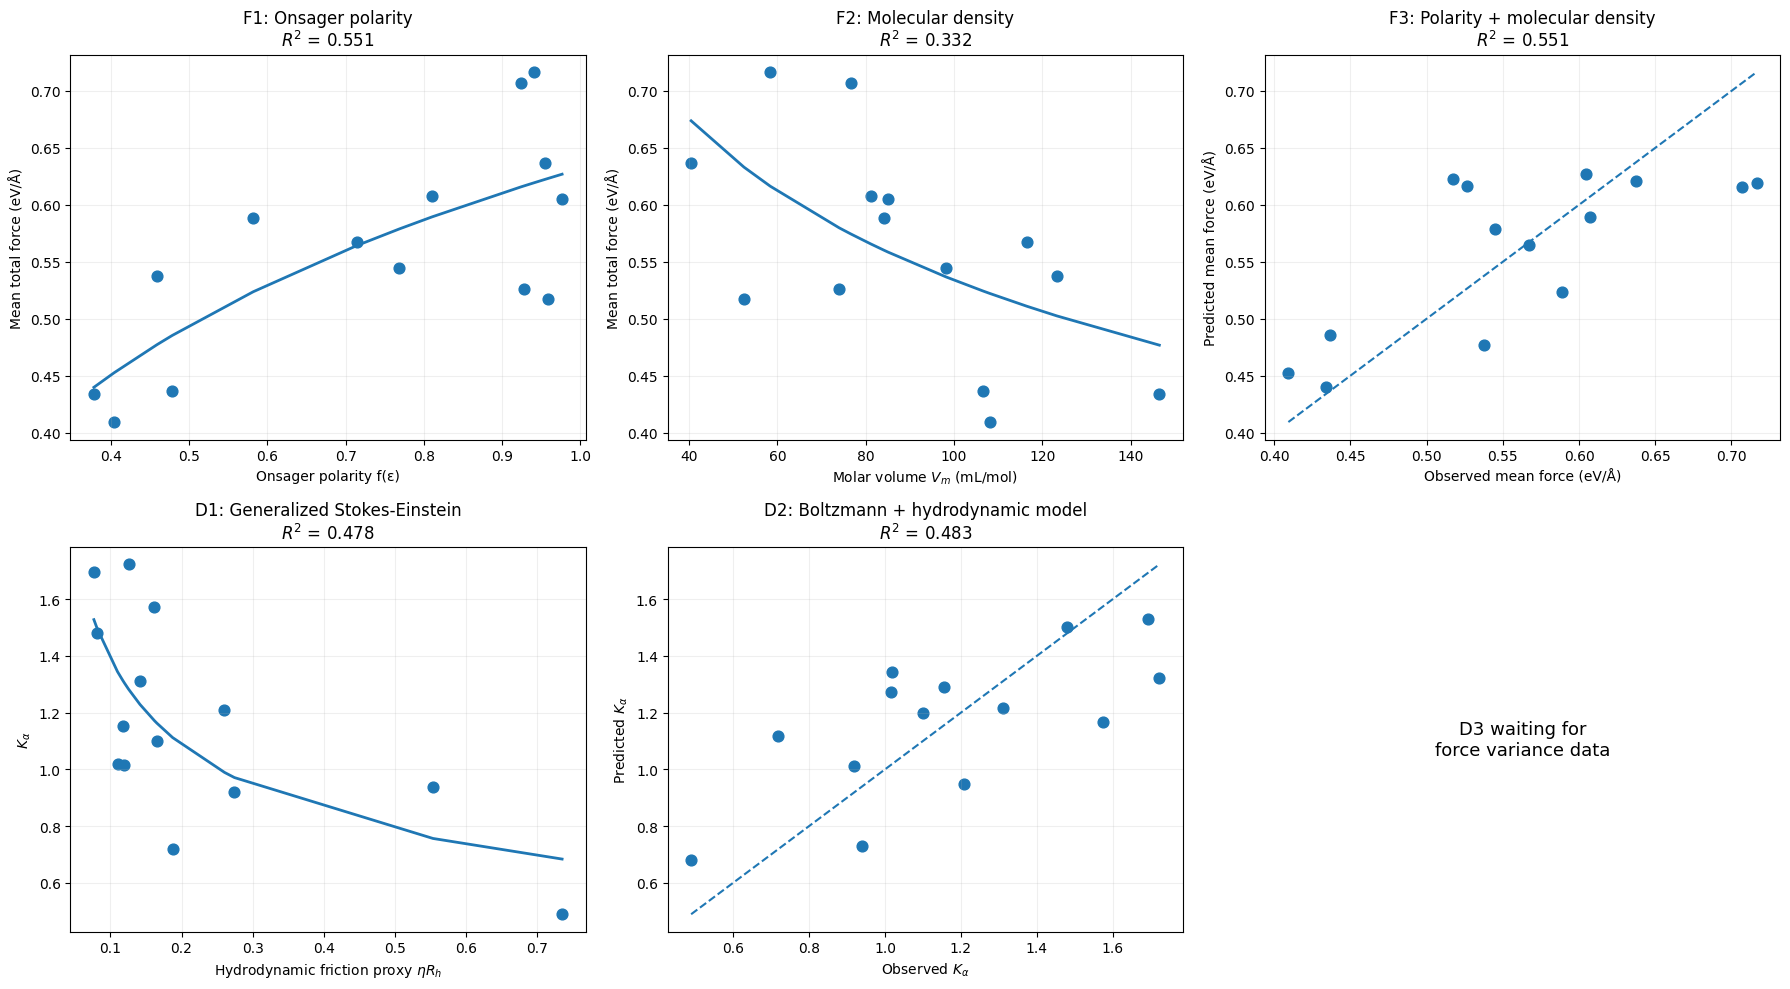



DERIVED SOLVENT PARAMETERS
            solvent         Vm  viscosity   Rh  friction_proxy  F_total  alpha  Kalpha
               CPME 116.463837      0.600 0.27         0.16200   0.5675 1.1050  1.5731
                DMC  84.184953      0.590 0.24         0.14160   0.5885 1.0305  1.3101
            acetone  73.986115      0.320 0.24         0.07680   0.5265 0.8760  1.6939
       acetonitrile  52.428991      0.370 0.22         0.08140   0.5174 0.8608  1.4791
        cyclohexane 108.035302      0.980 0.28         0.27440   0.4093 0.6273  0.9189
            ethanol  58.388340      1.085 0.24         0.26040   0.7165 0.8601  1.2076
      ethyl_acetate  98.221962      0.440 0.25         0.11000   0.5447 0.5924  1.0197
        isopropanol  76.554140      2.050 0.27         0.55350   0.7067 0.4635  0.9390
           methanol  40.456944      0.570 0.21         0.11970   0.6371 0.6732  1.0149
          n-heptane 146.494006      0.405 0.31         0.12555   0.4341 0.9057  1.7225
           p-x

In [ ]:
# ============================================================
# FINAL PHYSICAL MODEL ANALYSIS
#
# Physical framework:
#
# 1. Boltzmann / PMF
#       W(z) = -kBT ln g(z)
#       F(z) = -dW/dz
#
# 2. Onsager polarity
#       f(epsilon) = (epsilon - 1)/(2 epsilon + 1)
#
# 3. Stokes friction
#       zeta = 6*pi*eta*Rh
#
# 4. Generalized diffusion
#       K_alpha ~ (eta*Rh)^(-n)
#
# 5. Boltzmann activated transport
#       K_alpha ~ friction^(-n)
#                   * exp[-F*l/(kBT)]
#
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error


# ============================================================
# 1. DATA
# ============================================================

data = {

    "solvent": [
        "CPME",
        "DMC",
        "acetone",
        "acetonitrile",
        "cyclohexane",
        "ethanol",
        "ethyl_acetate",
        "isopropanol",
        "methanol",
        "n-heptane",
        "p-xylene",
        "propylene_carbonate",
        "THF",
        "toluene"
    ],

    "MW": [
        100.1589,
        90.0779,
        58.0791,
        41.0519,
        84.1595,
        46.0684,
        88.1051,
        60.095,
        32.0419,
        100.2019,
        106.165,
        102.0886,
        72.1057,
        92.1384
    ],

    "Onsager": [
        0.7148,
        0.5818,
        0.9285,
        0.9585,
        0.4039,
        0.9408,
        0.7688,
        0.9241,
        0.9547,
        0.3779,
        0.4586,
        0.9769,
        0.8107,
        0.4781
    ],

    "dipole": [
        1.27,
        0.91,
        2.88,
        3.92,
        0.0,
        1.44,
        1.78,
        1.58,
        1.70,
        0.0,
        0.0,
        4.94,
        1.63,
        0.33
    ],

    "F_total": [
        0.5675,
        0.5885,
        0.5265,
        0.5174,
        0.4093,
        0.7165,
        0.5447,
        0.7067,
        0.6371,
        0.4341,
        0.5378,
        0.6049,
        0.6075,
        0.4368
    ],

    "alpha": [
        1.1050,
        1.0305,
        0.8760,
        0.8608,
        0.6273,
        0.8601,
        0.5924,
        0.4635,
        0.6732,
        0.9057,
        0.4065,
        0.4251,
        0.6940,
        0.8920
    ],

    "Kalpha": [
        1.5731,
        1.3101,
        1.6939,
        1.4791,
        0.9189,
        1.2076,
        1.0197,
        0.9390,
        1.0149,
        1.7225,
        0.7182,
        0.4896,
        1.1545,
        1.1009
    ],

    "viscosity": [
        0.60,
        0.59,
        0.32,
        0.37,
        0.98,
        1.085,
        0.44,
        2.05,
        0.57,
        0.405,
        0.625,
        2.45,
        0.47,
        0.57
    ],

    "density": [
        0.860,
        1.070,
        0.785,
        0.783,
        0.779,
        0.789,
        0.897,
        0.785,
        0.792,
        0.684,
        0.861,
        1.200,
        0.889,
        0.8645
    ],

    "surface_tension": [
        24.5,
        28.5,
        23.5,
        28.5,
        25.25,
        22.05,
        23.75,
        21.35,
        22.35,
        20.25,
        28.5,
        41.5,
        26.25,
        28.1
    ],

    "Rh": [
        0.27,
        0.24,
        0.24,
        0.22,
        0.28,
        0.24,
        0.25,
        0.27,
        0.21,
        0.31,
        0.30,
        0.30,
        0.25,
        0.29
    ],

    # --------------------------------------------------------
    # optional force fluctuation
    #
    # Fill these when available:
    #
    # sigma_F2 = <F^2> - <F>^2
    #
    # Currently NaN -> D3 skipped automatically
    # --------------------------------------------------------

    "force_variance": [
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
}


df = pd.DataFrame(data)


# ============================================================
# 2. MOLAR VOLUME
# ============================================================

df["Vm"] = df["MW"] / df["density"]


# ============================================================
# 3. HYDRODYNAMIC FRICTION
#
# zeta ~ eta * Rh
#
# We mainly use this as a relative friction descriptor.
# ============================================================

df["friction_proxy"] = (
    df["viscosity"] *
    df["Rh"]
)


# ============================================================
# 4. FORCE IN SI
#
# eV/A -> N
#
# 1 eV/A = 1.602176634e-9 N
# ============================================================

df["F_SI"] = (
    df["F_total"]
    * 1.602176634e-9
)


# ============================================================
# 5. TEMPERATURE
#
# Your simulations/experimental solvent properties are around
# room temperature.
#
# Change if your MD temperature is different.
# ============================================================

T = 298.15

kB = 1.380649e-23

df["kBT"] = kB * T


# ============================================================
# 6. STATISTICS FUNCTION
# ============================================================

def statistics(y, y_pred, n_parameters):

    n = len(y)

    r2 = r2_score(y, y_pred)

    adjusted_r2 = (
        1
        - (1 - r2)
        * (n - 1)
        / (n - n_parameters - 1)
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            y_pred
        )
    )

    RSS = np.sum(
        (y - y_pred) ** 2
    )

    AIC = (
        n * np.log(RSS / n)
        + 2 * n_parameters
    )

    return r2, adjusted_r2, rmse, AIC


# ============================================================
# 7. MODEL RESULT STORAGE
# ============================================================

results = []

prediction_dict = {}


# ============================================================
# ============================================================
# FORCE MODELS
# ============================================================
# ============================================================


# ============================================================
# F1
#
# F = F0 + A*f^p
#
# This contains simple linear Onsager model as p = 1.
# ============================================================

def F1_model(f, F0, A, p):

    return F0 + A * f**p


f = df["Onsager"].values
y = df["F_total"].values

p0 = [
    0.3,
    0.3,
    1.0
]

bounds = (
    [-np.inf, -np.inf, 0.05],
    [np.inf, np.inf, 5.0]
)

popt, pcov = curve_fit(
    F1_model,
    f,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

y_pred = F1_model(
    f,
    *popt
)

r2, adj, rmse, aic = statistics(
    y,
    y_pred,
    3
)

prediction_dict["F1"] = y_pred

results.append({
    "Model": "F1",
    "Equation": "F = F0 + A*f^p",
    "R2": r2,
    "Adjusted_R2": adj,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# F2
#
# F = F0 + A*Vm^(-p)
# ============================================================

def F2_model(Vm, F0, A, p):

    return F0 + A * Vm**(-p)


Vm = df["Vm"].values

p0 = [
    0.3,
    5.0,
    1.0
]

bounds = (
    [-np.inf, -np.inf, 0.05],
    [np.inf, np.inf, 5.0]
)

popt, pcov = curve_fit(
    F2_model,
    Vm,
    y,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

y_pred = F2_model(
    Vm,
    *popt
)

r2, adj, rmse, aic = statistics(
    y,
    y_pred,
    3
)

prediction_dict["F2"] = y_pred

results.append({
    "Model": "F2",
    "Equation": "F = F0 + A*Vm^(-p)",
    "R2": r2,
    "Adjusted_R2": adj,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# F3
#
# F = F0 + A*f^p + B*Vm^(-q)
#
# More general combined model.
# ============================================================

def F3_model(X, F0, A, p, B, q):

    f, Vm = X

    return (
        F0
        + A * f**p
        + B * Vm**(-q)
    )


f = df["Onsager"].values
Vm = df["Vm"].values

p0 = [
    0.1,
    0.2,
    1.0,
    1.0,
    1.0
]

bounds = (
    [-np.inf, -np.inf, 0.05, -np.inf, 0.05],
    [np.inf, np.inf, 5.0, np.inf, 5.0]
)

popt, pcov = curve_fit(
    F3_model,
    (f, Vm),
    y,
    p0=p0,
    bounds=bounds,
    maxfev=50000
)

y_pred = F3_model(
    (f, Vm),
    *popt
)

r2, adj, rmse, aic = statistics(
    y,
    y_pred,
    5
)

prediction_dict["F3"] = y_pred

results.append({
    "Model": "F3",
    "Equation": "F = F0 + A*f^p + B*Vm^(-q)",
    "R2": r2,
    "Adjusted_R2": adj,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# ============================================================
# TAMSD MODELS
# ============================================================
# ============================================================


# ============================================================
# D1
#
# Generalized Stokes-Einstein
#
# Kα = A*(ηRh)^(-n)
# ============================================================

def D1_model(X, A, n):

    eta, Rh = X

    return (
        A
        * (eta * Rh) ** (-n)
    )


eta = df["viscosity"].values
Rh = df["Rh"].values
yK = df["Kalpha"].values

p0 = [
    1.0,
    1.0
]

popt, pcov = curve_fit(
    D1_model,
    (eta, Rh),
    yK,
    p0=p0,
    bounds=(
        [0, 0],
        [np.inf, 5]
    ),
    maxfev=20000
)

y_pred = D1_model(
    (eta, Rh),
    *popt
)

r2, adj, rmse, aic = statistics(
    yK,
    y_pred,
    2
)

prediction_dict["D1"] = y_pred

results.append({
    "Model": "D1",
    "Equation": "Kα = A*(ηRh)^(-n)",
    "R2": r2,
    "Adjusted_R2": adj,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# D2
#
# BOLTZMANN + STOKES ACTIVATED MODEL
#
# Kα =
#
# K0
# *
# (ηRh)^(-n)
# *
# exp[-F*l/(kBT)]
#
# l = effective interaction/hopping length
#
# ============================================================

def D2_model(X, K0, n, l_nm):

    eta, Rh, F_N = X

    # nm -> meter
    l = l_nm * 1e-9

    friction_term = (
        eta * Rh
    ) ** (-n)

    boltzmann_term = np.exp(
        -F_N * l / (kB * T)
    )

    return (
        K0
        * friction_term
        * boltzmann_term
    )


eta = df["viscosity"].values
Rh = df["Rh"].values
F_N = df["F_SI"].values

yK = df["Kalpha"].values


# initial guesses
p0 = [
    1.0,
    1.0,
    0.1
]

bounds = (
    [0, 0, 0.0001],
    [np.inf, 5, 100.0]
)

popt, pcov = curve_fit(
    D2_model,
    (eta, Rh, F_N),
    yK,
    p0=p0,
    bounds=bounds,
    maxfev=100000
)

y_pred = D2_model(
    (eta, Rh, F_N),
    *popt
)

r2, adj, rmse, aic = statistics(
    yK,
    y_pred,
    3
)

prediction_dict["D2"] = y_pred

results.append({
    "Model": "D2",
    "Equation": "Kα = K0*(ηRh)^(-n)*exp[-F*l/(kBT)]",
    "R2": r2,
    "Adjusted_R2": adj,
    "RMSE": rmse,
    "AIC": aic,
    "Parameters": popt
})


# ============================================================
# D3
#
# FORCE FLUCTUATION -> ANOMALOUS EXPONENT
#
# alpha =
#
# alpha0
# -
# A*ln(1 + sigmaF²/Fref²)
#
# ============================================================

def D3_model(X, alpha0, A, Fref):

    sigmaF2 = X

    return (
        alpha0
        - A
        * np.log(
            1
            + sigmaF2 / Fref**2
        )
    )


sigmaF2 = df[
    "force_variance"
].values

valid = (
    np.isfinite(sigmaF2)
)

if valid.sum() >= 5:

    x = sigmaF2[valid]
    ya = df.loc[
        valid,
        "alpha"
    ].values

    Fref0 = np.median(
        np.sqrt(x)
    )

    p0 = [
        1.0,
        0.1,
        max(Fref0, 1e-6)
    ]

    popt, pcov = curve_fit(
        D3_model,
        x,
        ya,
        p0=p0,
        bounds=(
            [-5, 0, 1e-8],
            [5, np.inf, np.inf]
        ),
        maxfev=50000
    )

    y_pred = D3_model(
        x,
        *popt
    )

    r2, adj, rmse, aic = statistics(
        ya,
        y_pred,
        3
    )

    # full prediction array
    full_pred = np.full(
        len(df),
        np.nan
    )

    full_pred[valid] = y_pred

    prediction_dict["D3"] = full_pred

    results.append({
        "Model": "D3",
        "Equation":
            "alpha = alpha0 - A*ln(1+sigmaF²/Fref²)",
        "R2": r2,
        "Adjusted_R2": adj,
        "RMSE": rmse,
        "AIC": aic,
        "Parameters": popt
    })

else:

    print(
        "\nD3 skipped:"
        " force_variance data are not available."
    )


# ============================================================
# 8. RESULTS
# ============================================================

result_df = pd.DataFrame(
    results
)

result_df = result_df.sort_values(
    "Adjusted_R2",
    ascending=False
)


print("\n")
print("=" * 100)
print("FINAL PHYSICAL MODEL COMPARISON")
print("=" * 100)

print(
    result_df[
        [
            "Model",
            "R2",
            "Adjusted_R2",
            "RMSE",
            "AIC"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 9. PARAMETERS
# ============================================================

print("\n")
print("=" * 100)
print("FITTED PARAMETERS")
print("=" * 100)

for _, row in result_df.iterrows():

    print("\n")
    print(row["Model"])
    print(row["Equation"])

    for i, p in enumerate(
        row["Parameters"]
    ):

        print(
            f"Parameter {i+1}: "
            f"{p:.8g}"
        )


# ============================================================
# 10. ADD PREDICTIONS
# ============================================================

for model, pred in prediction_dict.items():

    if model.startswith("F"):

        df[
            model + "_pred"
        ] = pred

    else:

        df[
            model + "_pred"
        ] = pred


# ============================================================
# 11. SAVE RESULTS
# ============================================================

result_df.to_csv(
    "FINAL_physical_model_statistics.csv",
    index=False
)

df.to_csv(
    "FINAL_physical_model_predictions.csv",
    index=False
)


# ============================================================
# 12. PLOTTING
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)


# ============================================================
# F1 PLOT
# ============================================================

ax = axes[0, 0]

x = df["Onsager"].values
y = df["F_total"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=60
)

ax.plot(
    x[idx],
    prediction_dict["F1"][idx],
    linewidth=2
)

row = result_df[
    result_df["Model"] == "F1"
].iloc[0]

ax.set_xlabel(
    "Onsager polarity f(ε)"
)

ax.set_ylabel(
    "Mean total force (eV/Å)"
)

ax.set_title(
    f"F1: Onsager polarity\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(
    alpha=0.2
)


# ============================================================
# F2
# ============================================================

ax = axes[0, 1]

x = df["Vm"].values
y = df["F_total"].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=60
)

ax.plot(
    x[idx],
    prediction_dict["F2"][idx],
    linewidth=2
)

row = result_df[
    result_df["Model"] == "F2"
].iloc[0]

ax.set_xlabel(
    r"Molar volume $V_m$ (mL/mol)"
)

ax.set_ylabel(
    "Mean total force (eV/Å)"
)

ax.set_title(
    f"F2: Molecular density\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(
    alpha=0.2
)


# ============================================================
# F3
# ============================================================

ax = axes[0, 2]

y = df["F_total"].values
y_pred = prediction_dict["F3"]

ax.scatter(
    y,
    y_pred,
    s=60
)

vmin = min(
    y.min(),
    y_pred.min()
)

vmax = max(
    y.max(),
    y_pred.max()
)

ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    linewidth=1.5
)

row = result_df[
    result_df["Model"] == "F3"
].iloc[0]

ax.set_xlabel(
    "Observed mean force (eV/Å)"
)

ax.set_ylabel(
    "Predicted mean force (eV/Å)"
)

ax.set_title(
    f"F3: Polarity + molecular density\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(
    alpha=0.2
)


# ============================================================
# D1
# ============================================================

ax = axes[1, 0]

x = df[
    "friction_proxy"
].values

y = df[
    "Kalpha"
].values

idx = np.argsort(x)

ax.scatter(
    x,
    y,
    s=60
)

ax.plot(
    x[idx],
    prediction_dict["D1"][idx],
    linewidth=2
)

row = result_df[
    result_df["Model"] == "D1"
].iloc[0]

ax.set_xlabel(
    r"Hydrodynamic friction proxy $\eta R_h$"
)

ax.set_ylabel(
    r"$K_\alpha$"
)

ax.set_title(
    f"D1: Generalized Stokes-Einstein\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(
    alpha=0.2
)


# ============================================================
# D2
# ============================================================

ax = axes[1, 1]

y = df["Kalpha"].values
y_pred = prediction_dict["D2"]

ax.scatter(
    y,
    y_pred,
    s=60
)

vmin = min(
    y.min(),
    y_pred.min()
)

vmax = max(
    y.max(),
    y_pred.max()
)

ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    linewidth=1.5
)

row = result_df[
    result_df["Model"] == "D2"
].iloc[0]

ax.set_xlabel(
    "Observed $K_α$"
)

ax.set_ylabel(
    "Predicted $K_α$"
)

ax.set_title(
    f"D2: Boltzmann + hydrodynamic model\n"
    f"$R^2$ = {row.R2:.3f}"
)

ax.grid(
    alpha=0.2
)


# ============================================================
# D3
# ============================================================

ax = axes[1, 2]

if "D3" in prediction_dict:

    x = df[
        "force_variance"
    ].values

    y = df[
        "alpha"
    ].values

    mask = np.isfinite(x)

    ax.scatter(
        x[mask],
        y[mask],
        s=60
    )

    idx = np.argsort(
        x[mask]
    )

    row = result_df[
        result_df["Model"] == "D3"
    ].iloc[0]

    ax.plot(
        x[mask][idx],
        prediction_dict["D3"][mask][idx],
        linewidth=2
    )

    ax.set_xlabel(
        r"Force variance $\sigma_F^2$"
    )

    ax.set_ylabel(
        r"TAMSD exponent $\alpha$"
    )

    ax.set_title(
        f"D3: Force landscape heterogeneity\n"
        f"$R^2$ = {row.R2:.3f}"
    )

else:

    ax.text(
        0.5,
        0.5,
        "D3 waiting for\nforce variance data",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=13
    )

    ax.set_axis_off()


plt.tight_layout()

plt.savefig(
    "FINAL_six_physical_models.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. MOLAR VOLUME + HYDRODYNAMIC PARAMETERS
# ============================================================

print("\n")
print("=" * 100)
print("DERIVED SOLVENT PARAMETERS")
print("=" * 100)

print(
    df[
        [
            "solvent",
            "Vm",
            "viscosity",
            "Rh",
            "friction_proxy",
            "F_total",
            "alpha",
            "Kalpha"
        ]
    ].to_string(
        index=False
    )
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FIGURE 1
# TMP → TEP → TnBP → TOP
# C1 → C2 → C4 → C8 alkyl-chain length effect
# ============================================================

phosphate = {
    "Phosphoric acid": {
        "C": None,
        "dd": 14.70,
        "dp": 18.60,
        "dh": 28.40,
    "TEP":  (2, 16.7, 11.4, 9.2),
    "TnBP": (4, 16.3,  6.3, 4.3),
    "TOP":  (8, 16.2,  5.9, 4.2),
}

names = list(phosphate.keys())

C = np.array([phosphate[x][0] for x in names])
dd = np.array([phosphate[x][1] for x in names])
dp = np.array([phosphate[x][2] for x in names])
dh = np.array([phosphate[x][3] for x in names])


fig, ax = plt.subplots(figsize=(8, 6))

# Main trajectory
ax.plot(
    dp,
    dh,
    "--o",
    linewidth=1.5,
    markersize=8
)

# Labels
for name, x, y, c in zip(names, dp, dh, C):

    ax.annotate(
        f"{name}\nC{c}",
        (x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )

# Direction arrows
for i in range(len(names) - 1):

    ax.annotate(
        "",
        xy=(dp[i+1], dh[i+1]),
        xytext=(dp[i], dh[i]),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2
        )
    )

# Main interpretation
ax.text(
    7.0,
    8.0,
    "Increasing alkyl-chain length\nC1 → C2 → C4 → C8",
    fontsize=11,
    ha="center"
)

ax.set_xlabel(
    r"$\delta_p$ (MPa$^{1/2}$)",
    fontsize=13
)

ax.set_ylabel(
    r"$\delta_h$ (MPa$^{1/2}$)",
    fontsize=13
)

ax.set_title(
    "Fig. 1. Alkyl-chain length effect on HSP",
    fontsize=14
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2
#
# Phosphoric acid
# C4-PA
# C8-PA (OPA)
# C18-PA (ODPA)
# C18-PA experimental
#
# ============================================================

pa = {

    "Phosphoric acid": {
        "C": None,
        "dd": 14.70,
        "dp": 18.60,
        "dh": 28.40,
    },

    "C4-PA": {
        "C": 4,
        "dd": 17.01,
        "dp": 15.70,
        "dh": 18.60,
    },

    "C8-PA\n(OPA-Mathieu)": {
        "C": 8,
        "dd": 16.59,
        "dp": 12.52,
        "dh": 14.87,
    },

    "C18-PA\n(ODPA-Mathieu)": {
        "C": 18,
        "dd": 16.22,
        "dp": 9.06,
        "dh": 10.82,
    },

    "C18-PA\n(ODPA-exp)": {
        "C": 18,
        "dd": 16.90,
        "dp": 5.40,
        "dh": 11.70,
    }
}


fig, ax = plt.subplots(figsize=(9, 7))


# ------------------------------------------------------------
# Plot points
# ------------------------------------------------------------

for name, d in pa.items():

    ax.scatter(
        d["dp"],
        d["dh"],
        s=110,
        zorder=5
    )

    # Label positions
    if "Phosphoric" in name:
        offset = (8, 8)

    elif "C4" in name:
        offset = (8, 8)

    elif "C8" in name:
        offset = (8, 8)

    elif "ODPA-Mathieu" in name:
        offset = (8, -20)

    else:
        offset = (8, 8)

    ax.annotate(
        name,
        (d["dp"], d["dh"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=11
    )


# ------------------------------------------------------------
# C4 → C8 → C18 Mathieu trajectory
# ------------------------------------------------------------

C4 = pa["C4-PA"]
C8 = pa["C8-PA\n(OPA-Mathieu)"]
C18 = pa["C18-PA\n(ODPA-Mathieu)"]

x_mathieu = [
    C4["dp"],
    C8["dp"],
    C18["dp"]
]

y_mathieu = [
    C4["dh"],
    C8["dh"],
    C18["dh"]
]

ax.plot(
    x_mathieu,
    y_mathieu,
    "--",
    linewidth=1.5,
    zorder=2
)


# Direction arrows for C4 → C8 → C18
for p1, p2 in zip(
    range(len(x_mathieu) - 1),
    range(1, len(x_mathieu))
):

    ax.annotate(
        "",
        xy=(x_mathieu[p2], y_mathieu[p2]),
        xytext=(x_mathieu[p1], y_mathieu[p1]),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.2
        )
    )


# ------------------------------------------------------------
# Annotation: chain length
# ------------------------------------------------------------

ax.text(
    12.0,
    15.8,
    "Increasing alkyl-chain length\nC4 → C8 → C18",
    fontsize=11,
    ha="center"
)


# ------------------------------------------------------------
# ODPA Mathieu → experimental shift
# ------------------------------------------------------------

ODPA_exp = pa["C18-PA\n(ODPA-exp)"]

ax.annotate(
    "",
    xy=(ODPA_exp["dp"], ODPA_exp["dh"]),
    xytext=(C18["dp"], C18["dh"]),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    )
)

ax.text(
    6.9,
    10.5,
    "Mathieu → experimental\nHSP shift",
    fontsize=10,
    ha="center"
)


# ------------------------------------------------------------
# Experimental R0
# ------------------------------------------------------------

R0 = 3.7

circle = plt.Circle(
    (ODPA_exp["dp"], ODPA_exp["dh"]),
    R0,
    fill=False,
    linestyle=":",
    linewidth=1.2
)

ax.add_patch(circle)

ax.text(
    ODPA_exp["dp"] + 1.5,
    ODPA_exp["dh"] - 1.5,
    r"$R_0=3.7$",
    fontsize=10
)


# ------------------------------------------------------------
# Headgroup reference
# ------------------------------------------------------------

ax.text(
    18.2,
    25.5,
    "Highly polar /\nH-bonding\nheadgroup",
    fontsize=11,
    ha="center"
)


# ------------------------------------------------------------
# Axis
# ------------------------------------------------------------

ax.set_xlabel(
    r"$\delta_p$ (MPa$^{1/2}$)",
    fontsize=13
)

ax.set_ylabel(
    r"$\delta_h$ (MPa$^{1/2}$)",
    fontsize=13
)

ax.set_title(
    "Fig. 2. HSP evolution of phosphonic-acid alkyl chains",
    fontsize=14
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# OPTIONAL:
# Quantify the chain-length dependence
# ============================================================

C_chain = np.array([4, 8, 18])

dp_chain = np.array([
    15.70,
    12.52,
    9.06
])

dh_chain = np.array([
    18.60,
    14.87,
    10.82
])

dd_chain = np.array([
    17.01,
    16.59,
    16.22
])


# Linear fitting
fit_dp = np.polyfit(C_chain, dp_chain, 1)
fit_dh = np.polyfit(C_chain, dh_chain, 1)
fit_dd = np.polyfit(C_chain, dd_chain, 1)

print("δp vs C:")
print(f"δp = {fit_dp[0]:.4f} C + {fit_dp[1]:.4f}")

print("\nδh vs C:")
print(f"δh = {fit_dh[0]:.4f} C + {fit_dh[1]:.4f}")

print("\nδd vs C:")
print(f"δd = {fit_dd[0]:.4f} C + {fit_dd[1]:.4f}")

SyntaxError: '{' was never closed (1474093209.py, line 11)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# FIGURE 1 (3D)
# Phosphoric acid → TMP → TEP → TBP (TnBP) → TOP
# ============================================================

# 统一解析数据（将元组转为字典）
phosphate_data = {
    "Phosphoric acid": {"C": 0, "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "TMP":            {"C": 1, "dd": 15.7,  "dp": 10.5,  "dh": 10.2},
    "TEP":            {"C": 2, "dd": 16.7,  "dp": 11.4,  "dh": 9.2},
    "TBP":            {"C": 4, "dd": 16.3,  "dp": 6.3,   "dh": 4.3},   # 原 TnBP
    "TOP":            {"C": 8, "dd": 16.2,  "dp": 5.9,   "dh": 4.2},
}

# 按碳数排序
names1 = sorted(phosphate_data.keys(), key=lambda n: phosphate_data[n]["C"])
dd1 = np.array([phosphate_data[n]["dd"] for n in names1])
dp1 = np.array([phosphate_data[n]["dp"] for n in names1])
dh1 = np.array([phosphate_data[n]["dh"] for n in names1])
C1  = np.array([phosphate_data[n]["C"]  for n in names1])

fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')

# 轨迹线 + 点
ax1.plot(dp1, dh1, dd1, '--o', linewidth=1.5, markersize=8, zorder=3, label='Chain length increase')

# 标注点
for name, x, y, z, c in zip(names1, dp1, dh1, dd1, C1):
    # 偏移量调整
    offset = (0.5, 0.5, 0.5) if name != "Phosphoric acid" else (0, 0, 2)
    ax1.text(x + offset[0], y + offset[1], z + offset[2],
             f"{name}\nC{c}", fontsize=10, ha='center', va='center')

# 方向箭头（用 quiver 沿轨迹分段绘制）
for i in range(len(names1)-1):
    x1_, y1_, z1_ = dp1[i], dh1[i], dd1[i]
    x2_, y2_, z2_ = dp1[i+1], dh1[i+1], dd1[i+1]
    # 取线段中间位置画箭头
    mid_x = (x1_ + x2_) / 2
    mid_y = (y1_ + y2_) / 2
    mid_z = (z1_ + z2_) / 2
    dx = x2_ - x1_
    dy = y2_ - y1_
    dz = z2_ - z1_
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    if length > 0:
        # 归一化后缩放为线段长度的 30%
        scale = 0.3
        ax1.quiver(mid_x, mid_y, mid_z,
                   dx * scale, dy * scale, dz * scale,
                   arrow_length_ratio=0.3, color='black', linewidth=1.2)

# 注解文字
ax1.text(dp1[2]-1, dh1[2]-2, dd1[2]+2,
         "Increasing alkyl-chain length\nC0 → C1 → C2 → C4 → C8",
         fontsize=11, ha='center', va='center', color='darkred')

ax1.set_xlabel(r'$\delta_p$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax1.set_ylabel(r'$\delta_h$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax1.set_zlabel(r'$\delta_d$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax1.set_title("Fig. 1. Alkyl-chain length effect on HSP (3D)", fontsize=14)
ax1.view_init(elev=25, azim=50)
plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 (3D)
# Phosphoric acid → C4-PA → C8-PA (OPA-Mathieu) → C18-PA (ODPA-Mathieu)
# plus experimental ODPA and R0 annotation
# ============================================================

pa_data = {
    "Phosphoric acid":         {"C": 0,  "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "C4-PA":                   {"C": 4,  "dd": 17.01, "dp": 15.70, "dh": 18.60},
    "C8-PA (OPA-Mathieu)":     {"C": 8,  "dd": 16.59, "dp": 12.52, "dh": 14.87},
    "C18-PA (ODPA-Mathieu)":   {"C": 18, "dd": 16.22, "dp": 9.06,  "dh": 10.82},
    "C18-PA (ODPA-exp)":       {"C": 18, "dd": 16.90, "dp": 5.40,  "dh": 11.70},
}

names2 = list(pa_data.keys())
dd2 = np.array([pa_data[n]["dd"] for n in names2])
dp2 = np.array([pa_data[n]["dp"] for n in names2])
dh2 = np.array([pa_data[n]["dh"] for n in names2])

fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

# 绘制所有散点
for name, x, y, z in zip(names2, dp2, dh2, dd2):
    ax2.scatter(x, y, z, s=80, zorder=5)
    # 偏移调整
    if "Phosphoric" in name:
        off = (0, 0, 2)
    elif "C4" in name:
        off = (0.5, 0.5, 0.5)
    elif "C8" in name:
        off = (0.5, 0.5, 0.5)
    elif "ODPA-Mathieu" in name:
        off = (0.5, -0.5, 0.5)
    else:  # experimental
        off = (0.5, 0.5, 0.5)
    ax2.text(x + off[0], y + off[1], z + off[2],
             name, fontsize=9, ha='center', va='center')

# 绘制 Mathieu 轨迹（C4 → C8 → C18）
mathieu_names = ["C4-PA", "C8-PA (OPA-Mathieu)", "C18-PA (ODPA-Mathieu)"]
x_m = [pa_data[n]["dp"] for n in mathieu_names]
y_m = [pa_data[n]["dh"] for n in mathieu_names]
z_m = [pa_data[n]["dd"] for n in mathieu_names]
ax2.plot(x_m, y_m, z_m, '--', linewidth=1.5, color='blue', zorder=2)

# 方向箭头（Mathieu轨迹）
for i in range(len(x_m)-1):
    mid_x = (x_m[i] + x_m[i+1]) / 2
    mid_y = (y_m[i] + y_m[i+1]) / 2
    mid_z = (z_m[i] + z_m[i+1]) / 2
    dx = x_m[i+1] - x_m[i]
    dy = y_m[i+1] - y_m[i]
    dz = z_m[i+1] - z_m[i]
    length = np.sqrt(dx**2 + dy**2 + dz**2)
    if length > 0:
        scale = 0.3
        ax2.quiver(mid_x, mid_y, mid_z,
                   dx*scale, dy*scale, dz*scale,
                   arrow_length_ratio=0.3, color='blue', linewidth=1.2)

# 从 Mathieu C18 到 experimental 的箭头
c18_math = pa_data["C18-PA (ODPA-Mathieu)"]
c18_exp   = pa_data["C18-PA (ODPA-exp)"]
ax2.quiver(c18_math["dp"], c18_math["dh"], c18_math["dd"],
           (c18_exp["dp"]-c18_math["dp"])*0.5,
           (c18_exp["dh"]-c18_math["dh"])*0.5,
           (c18_exp["dd"]-c18_math["dd"])*0.5,
           arrow_length_ratio=0.3, color='red', linewidth=1.5)
ax2.text((c18_math["dp"]+c18_exp["dp"])/2 - 1,
         (c18_math["dh"]+c18_exp["dh"])/2,
         (c18_math["dd"]+c18_exp["dd"])/2 + 1,
         "Mathieu → exp", fontsize=9, ha='center', color='red')

# 标注 R0 = 3.7 (在 exp 点附近)
ax2.text(c18_exp["dp"] + 1.5, c18_exp["dh"] - 1.5, c18_exp["dd"] + 0.5,
         r"$R_0=3.7$", fontsize=10, color='green')

# 添加“Highly polar headgroup”注解（放在 Phosphoric acid 附近）
pa0 = pa_data["Phosphoric acid"]
ax2.text(pa0["dp"] + 1, pa0["dh"] - 2, pa0["dd"] + 2,
         "Highly polar /\nH-bonding headgroup",
         fontsize=10, ha='center', va='center', color='purple')

# 增加 chain length 说明
ax2.text(x_m[1]-1, y_m[1]-1.5, z_m[1]+2,
         "Increasing alkyl-chain length\nC4 → C8 → C18",
         fontsize=11, ha='center', color='darkblue')

ax2.set_xlabel(r'$\delta_p$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax2.set_ylabel(r'$\delta_h$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax2.set_zlabel(r'$\delta_d$ (MPa$^{1/2}$)', fontsize=13, labelpad=10)
ax2.set_title("Fig. 2. HSP evolution of phosphonic-acid alkyl chains (3D)", fontsize=14)
ax2.view_init(elev=20, azim=60)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 溶剂数据（按表）
# ============================================================
solvents = [
    {"name": "CPME",                "dd": 16.7, "dp": 4.3,  "dh": 4.3},
    {"name": "DMC",                 "dd": 15.5, "dp": 8.6,  "dh": 9.7},
    {"name": "n-Heptane",           "dd": 15.3, "dp": 0.0,  "dh": 0.0},
    {"name": "Toluene",             "dd": 18.0, "dp": 1.4,  "dh": 2.0},
    {"name": "Acetone",             "dd": 15.5, "dp": 10.4, "dh": 7.0},
    {"name": "Acetonitrile",        "dd": 15.3, "dp": 18.0, "dh": 6.1},
    {"name": "Ethanol",             "dd": 15.8, "dp": 8.8,  "dh": 19.4},
    {"name": "THF",                 "dd": 16.8, "dp": 5.7,  "dh": 8.0},
    {"name": "Methanol",            "dd": 14.7, "dp": 12.3, "dh": 22.3},
    {"name": "Cyclohexane",         "dd": 16.8, "dp": 0.0,  "dh": 0.2},
    {"name": "Ethyl acetate",       "dd": 15.8, "dp": 5.3,  "dh": 7.2},
    {"name": "Isopropanol",         "dd": 15.8, "dp": 6.1,  "dh": 16.4},
    {"name": "Propylene carbonate", "dd": 20.0, "dp": 18.0, "dh": 4.1},
    {"name": "p-Xylene",            "dd": 17.8, "dp": 1.0,  "dh": 3.1},
]

# 提取溶剂坐标（用于散点）
solv_dd = [s["dd"] for s in solvents]
solv_dp = [s["dp"] for s in solvents]
solv_dh = [s["dh"] for s in solvents]

# ============================================================
# 图1数据：磷酸酯系列（C0 → C1 → C2 → C4 → C8）
# ============================================================
phosphate_data = {
    "Phosphoric acid": {"C": 0,  "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "TMP":            {"C": 1,  "dd": 15.7,  "dp": 10.5,  "dh": 10.2},
    "TEP":            {"C": 2,  "dd": 16.7,  "dp": 11.4,  "dh": 9.2},
    "TBP":            {"C": 4,  "dd": 16.3,  "dp": 6.3,   "dh": 4.3},   # 原 TnBP
    "TOP":            {"C": 8,  "dd": 16.2,  "dp": 5.9,   "dh": 4.2},
}
# 按碳数排序
names_ph = sorted(phosphate_data.keys(), key=lambda n: phosphate_data[n]["C"])
dd_ph = [phosphate_data[n]["dd"] for n in names_ph]
dp_ph = [phosphate_data[n]["dp"] for n in names_ph]
dh_ph = [phosphate_data[n]["dh"] for n in names_ph]

# ============================================================
# 图2数据：膦酸系列（C0 → C4 → C8 → C18 Mathieu → exp）
# ============================================================
pa_data = {
    "Phosphoric acid":          {"C": 0,  "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "C4-PA":                    {"C": 4,  "dd": 17.01, "dp": 15.70, "dh": 18.60},
    "C8-PA (OPA-Mathieu)":      {"C": 8,  "dd": 16.59, "dp": 12.52, "dh": 14.87},
    "C18-PA (ODPA-Mathieu)":    {"C": 18, "dd": 16.22, "dp": 9.06,  "dh": 10.82},
    "C18-PA (ODPA-exp)":        {"C": 18, "dd": 16.90, "dp": 5.40,  "dh": 11.70},
}
names_pa = list(pa_data.keys())
dd_pa = [pa_data[n]["dd"] for n in names_pa]
dp_pa = [pa_data[n]["dp"] for n in names_pa]
dh_pa = [pa_data[n]["dh"] for n in names_pa]

# ============================================================
# 绘图函数：绘制一个子图（投影）
# ============================================================
def plot_projection(ax, xdata, ydata, xlabel, ylabel, title,
                    data_names, dd_vals, dp_vals, dh_vals,
                    add_extra=False, extra_params=None):
    """
    绘制投影图：
      xdata, ydata 是数据点坐标（列表）
      data_names 是数据点名称
      dd_vals, dp_vals, dh_vals 用于额外信息（如箭头）
      add_extra: 是否添加特殊标注（用于图2的Mathieu→exp和R0）
      extra_params: 包含额外数据的字典
    """
    # 绘制数据集轨迹（线+点）
    ax.plot(xdata, ydata, '--o', linewidth=1.5, markersize=8, color='tab:blue',
            label='Chain growth', zorder=3)
    # 标注数据集点（使用简写名称）
    for name, x, y in zip(data_names, xdata, ydata):
        # 简化名称（去掉多余空格和括号）
        short = name.replace(" (OPA-Mathieu)", "").replace(" (ODPA-Mathieu)", "").replace(" (ODPA-exp)", "")
        if "Phosphoric" in short:
            short = "H3PO4"
        ax.annotate(short, (x, y), xytext=(4, 4), textcoords='offset points',
                    fontsize=8, color='tab:blue')

    # 绘制所有溶剂点（小散点，不同颜色）
    ax.scatter(solv_dp, solv_dh, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)
    # 注意：这里溶剂坐标根据投影轴选择正确变量，但我们是通用函数，需要传入正确变量
    # 实际上该函数只使用传入的xdata/ydata，溶剂点需根据投影轴选择对应的坐标。
    # 因此，这里在外部调用时已分别传入溶剂的对应坐标。

    # 添加额外标注（仅用于图2的某些投影）
    if add_extra and extra_params:
        # 绘制 Mathieu → exp 箭头（在δp-δh投影中）
        if 'arrow' in extra_params:
            ax.annotate("", xy=extra_params['arrow_end'], xytext=extra_params['arrow_start'],
                        arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
            ax.text((extra_params['arrow_start'][0]+extra_params['arrow_end'][0])/2 - 0.5,
                    (extra_params['arrow_start'][1]+extra_params['arrow_end'][1])/2,
                    "Mathieu→exp", fontsize=8, color='red', ha='center')
        if 'R0' in extra_params:
            ax.text(extra_params['R0_pos'][0]+0.5, extra_params['R0_pos'][1]-0.5,
                    r"$R_0=3.7$", fontsize=8, color='green')

    # 添加“Increasing chain length”文字（放在轨迹中间）
    mid_idx = len(xdata)//2
    if mid_idx < len(xdata):
        ax.text(xdata[mid_idx]+0.5, ydata[mid_idx]-1.0,
                "Chain length↑", fontsize=8, color='tab:blue', ha='center')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='best', fontsize=8)

# ============================================================
# 创建六张子图（2行×3列）
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---- 第一行：磷酸酯系列（图1）的三个投影 ----
# 投影1：δp vs δh
ax = axes[0,0]
plot_projection(ax, dp_ph, dh_ph, r'$\delta_p$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
                'Phosphate esters: δp–δh', names_ph, dd_ph, dp_ph, dh_ph)
# 注意：溶剂点需与投影轴对应，这里应使用溶剂dp和dh
ax.scatter(solv_dp, solv_dh, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# 投影2：δd vs δp
ax = axes[0,1]
plot_projection(ax, dd_ph, dp_ph, r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_p$ (MPa$^{1/2}$)',
                'Phosphate esters: δd–δp', names_ph, dd_ph, dp_ph, dh_ph)
ax.scatter(solv_dd, solv_dp, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# 投影3：δd vs δh
ax = axes[0,2]
plot_projection(ax, dd_ph, dh_ph, r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
                'Phosphate esters: δd–δh', names_ph, dd_ph, dp_ph, dh_ph)
ax.scatter(solv_dd, solv_dh, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# ---- 第二行：膦酸系列（图2）的三个投影 ----
# 对于图2，在δp-δh投影中额外添加 Mathieu→exp 箭头和 R0 标注
# 准备额外参数
extra = {
    'arrow_start': (pa_data["C18-PA (ODPA-Mathieu)"]["dp"], pa_data["C18-PA (ODPA-Mathieu)"]["dh"]),
    'arrow_end':   (pa_data["C18-PA (ODPA-exp)"]["dp"],       pa_data["C18-PA (ODPA-exp)"]["dh"]),
    'R0_pos':      (pa_data["C18-PA (ODPA-exp)"]["dp"],       pa_data["C18-PA (ODPA-exp)"]["dh"])
}

# 投影4：δp vs δh（带额外信息）
ax = axes[1,0]
plot_projection(ax, dp_pa, dh_pa, r'$\delta_p$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
                'Phosphonic acids: δp–δh', names_pa, dd_pa, dp_pa, dh_pa,
                add_extra=True, extra_params=extra)
ax.scatter(solv_dp, solv_dh, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# 投影5：δd vs δp（不加额外标注）
ax = axes[1,1]
plot_projection(ax, dd_pa, dp_pa, r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_p$ (MPa$^{1/2}$)',
                'Phosphonic acids: δd–δp', names_pa, dd_pa, dp_pa, dh_pa)
ax.scatter(solv_dd, solv_dp, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# 投影6：δd vs δh（不加额外标注）
ax = axes[1,2]
plot_projection(ax, dd_pa, dh_pa, r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
                'Phosphonic acids: δd–δh', names_pa, dd_pa, dp_pa, dh_pa)
ax.scatter(solv_dd, solv_dh, s=30, color='red', alpha=0.7, label='Solvents', zorder=2)

# 调整布局并显示
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. 定义所有溶剂及其介电常数（近似值，室温）
# ============================================================
dielectric = {
    "Phosphoric acid": 61.0,
    "TMP": 7.5,
    "TEP": 7.0,
    "TBP": 4.5,
    "TOP": 3.0,
    "C4-PA": 5.0,
    "C8-PA (OPA-Mathieu)": 4.0,
    "C18-PA (ODPA-Mathieu)": 3.5,
    "C18-PA (ODPA-exp)": 3.5,
    "CPME": 4.5,
    "DMC": 3.1,
    "n-Heptane": 1.9,
    "Toluene": 2.4,
    "Acetone": 20.7,
    "Acetonitrile": 37.5,
    "Ethanol": 24.6,
    "THF": 7.5,
    "Methanol": 32.7,
    "Cyclohexane": 2.0,
    "Ethyl acetate": 6.0,
    "Isopropanol": 19.9,
    "Propylene carbonate": 64.0,
    "p-Xylene": 2.3,
}

# ============================================================
# 2. 溶剂数据列表（用于绘图）
# ============================================================
solvents = [
    {"name": "CPME",                "dd": 16.7, "dp": 4.3,  "dh": 4.3},
    {"name": "DMC",                 "dd": 15.5, "dp": 8.6,  "dh": 9.7},
    {"name": "n-Heptane",           "dd": 15.3, "dp": 0.0,  "dh": 0.0},
    {"name": "Toluene",             "dd": 18.0, "dp": 1.4,  "dh": 2.0},
    {"name": "Acetone",             "dd": 15.5, "dp": 10.4, "dh": 7.0},
    {"name": "Acetonitrile",        "dd": 15.3, "dp": 18.0, "dh": 6.1},
    {"name": "Ethanol",             "dd": 15.8, "dp": 8.8,  "dh": 19.4},
    {"name": "THF",                 "dd": 16.8, "dp": 5.7,  "dh": 8.0},
    {"name": "Methanol",            "dd": 14.7, "dp": 12.3, "dh": 22.3},
    {"name": "Cyclohexane",         "dd": 16.8, "dp": 0.0,  "dh": 0.2},
    {"name": "Ethyl acetate",       "dd": 15.8, "dp": 5.3,  "dh": 7.2},
    {"name": "Isopropanol",         "dd": 15.8, "dp": 6.1,  "dh": 16.4},
    {"name": "Propylene carbonate", "dd": 20.0, "dp": 18.0, "dh": 4.1},
    {"name": "p-Xylene",            "dd": 17.8, "dp": 1.0,  "dh": 3.1},
]
# 提取溶剂坐标
solv_names = [s["name"] for s in solvents]
solv_dd = [s["dd"] for s in solvents]
solv_dp = [s["dp"] for s in solvents]
solv_dh = [s["dh"] for s in solvents]

# ============================================================
# 3. 磷酸酯系列（图1）
# ============================================================
phosphate_data = {
    "Phosphoric acid": {"C": 0,  "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "TMP":            {"C": 1,  "dd": 15.7,  "dp": 10.5,  "dh": 10.2},
    "TEP":            {"C": 2,  "dd": 16.7,  "dp": 11.4,  "dh": 9.2},
    "TBP":            {"C": 4,  "dd": 16.3,  "dp": 6.3,   "dh": 4.3},
    "TOP":            {"C": 8,  "dd": 16.2,  "dp": 5.9,   "dh": 4.2},
}
names_ph = sorted(phosphate_data.keys(), key=lambda n: phosphate_data[n]["C"])
dd_ph = [phosphate_data[n]["dd"] for n in names_ph]
dp_ph = [phosphate_data[n]["dp"] for n in names_ph]
dh_ph = [phosphate_data[n]["dh"] for n in names_ph]

# ============================================================
# 4. 膦酸系列（图2）
# ============================================================
pa_data = {
    "Phosphoric acid":          {"C": 0,  "dd": 14.70, "dp": 18.60, "dh": 28.40},
    "C4-PA":                    {"C": 4,  "dd": 17.01, "dp": 15.70, "dh": 18.60},
    "C8-PA (OPA-Mathieu)":      {"C": 8,  "dd": 16.59, "dp": 12.52, "dh": 14.87},
    "C18-PA (ODPA-Mathieu)":    {"C": 18, "dd": 16.22, "dp": 9.06,  "dh": 10.82},
    "C18-PA (ODPA-exp)":        {"C": 18, "dd": 16.90, "dp": 5.40,  "dh": 11.70},
}
names_pa = list(pa_data.keys())
dd_pa = [pa_data[n]["dd"] for n in names_pa]
dp_pa = [pa_data[n]["dp"] for n in names_pa]
dh_pa = [pa_data[n]["dh"] for n in names_pa]

# ============================================================
# 5. 准备颜色映射（介电常数归一化）
# ============================================================
# 合并所有溶剂名称（去重）
all_names = list(set(solv_names) | set(phosphate_data.keys()) | set(pa_data.keys()))
# 获取介电常数（默认0以防缺失）
eps = [dielectric.get(name, 0.0) for name in all_names]
eps_min, eps_max = min(eps), max(eps)
norm = mpl.colors.Normalize(vmin=eps_min, vmax=eps_max)
cmap = plt.cm.RdYlGn  # 低→红，高→绿

# 为每个溶剂分配颜色（用于散点）
def get_color(name):
    return cmap(norm(dielectric.get(name, 0.0)))

# 为solvents列表中的每个溶剂分配颜色（用于绘图）
solv_colors = [get_color(s["name"]) for s in solvents]

# ============================================================
# 6. 绘图：2行×3列，外加底部图例栏
# ============================================================
fig = plt.figure(figsize=(16, 12))
# 调整子图位置，为底部图例留空间
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.25, bottom=0.22, top=0.92, left=0.08, right=0.92)
axes = []
for i in range(2):
    for j in range(3):
        ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

# 定义绘制子图的函数
def plot_subplot(ax, xdata, ydata, xlabel, ylabel, title, data_names,
                 dd_vals, dp_vals, dh_vals, add_extra=False):
    # 绘制轨迹（克莱因蓝）
    ax.plot(xdata, ydata, '--o', linewidth=1.8, markersize=7,
            color='#002FA7', label='Chain growth', zorder=3)
    # 标注数据点（简写）
    for name, x, y in zip(data_names, xdata, ydata):
        short = name.replace(" (OPA-Mathieu)", "").replace(" (ODPA-Mathieu)", "").replace(" (ODPA-exp)", "")
        if "Phosphoric" in short:
            short = "H₃PO₄"
        ax.annotate(short, (x, y), xytext=(3, 3), textcoords='offset points',
                    fontsize=8, color='#002FA7')
    # 添加链增长方向文字
    mid = len(xdata)//2
    if mid < len(xdata):
        ax.text(xdata[mid]+0.5, ydata[mid]-1.0, "Chain length↑",
                fontsize=8, color='#002FA7', ha='center')
    # 绘制所有溶剂散点（颜色映射介电常数）
    ax.scatter(solv_dp, solv_dh, s=30, c=solv_colors, alpha=0.8, label='Solvents', zorder=2)
    # 额外标注（第二行δp-δh）
    if add_extra:
        # Mathieu → exp 箭头
        c18_math = pa_data["C18-PA (ODPA-Mathieu)"]
        c18_exp   = pa_data["C18-PA (ODPA-exp)"]
        ax.annotate("", xy=(c18_exp["dp"], c18_exp["dh"]),
                    xytext=(c18_math["dp"], c18_math["dh"]),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.8))
        ax.text((c18_math["dp"]+c18_exp["dp"])/2 - 0.5,
                (c18_math["dh"]+c18_exp["dh"])/2,
                "Mathieu→exp", fontsize=8, color='red', ha='center')
        # R0标注
        ax.text(c18_exp["dp"]+0.5, c18_exp["dh"]-0.5, r"$R_0=3.7$",
                fontsize=8, color='green')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    # 只显示一个图例（第一行第一列展示）
    if ax == axes[0]:
        ax.legend(loc='best', fontsize=8)

# ---- 第一行：磷酸酯 ----
# (0,0) δp–δh
plot_subplot(axes[0], dp_ph, dh_ph,
             r'$\delta_p$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
             'Phosphate esters: δp–δh', names_ph, dd_ph, dp_ph, dh_ph)
# (0,1) δd–δp
plot_subplot(axes[1], dd_ph, dp_ph,
             r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_p$ (MPa$^{1/2}$)',
             'Phosphate esters: δd–δp', names_ph, dd_ph, dp_ph, dh_ph)
# (0,2) δd–δh
plot_subplot(axes[2], dd_ph, dh_ph,
             r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
             'Phosphate esters: δd–δh', names_ph, dd_ph, dp_ph, dh_ph)

# ---- 第二行：膦酸 ----
# (1,0) δp–δh（额外标注）
plot_subplot(axes[3], dp_pa, dh_pa,
             r'$\delta_p$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
             'Phosphonic acids: δp–δh', names_pa, dd_pa, dp_pa, dh_pa,
             add_extra=True)
# (1,1) δd–δp
plot_subplot(axes[4], dd_pa, dp_pa,
             r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_p$ (MPa$^{1/2}$)',
             'Phosphonic acids: δd–δp', names_pa, dd_pa, dp_pa, dh_pa)
# (1,2) δd–δh
plot_subplot(axes[5], dd_pa, dh_pa,
             r'$\delta_d$ (MPa$^{1/2}$)', r'$\delta_h$ (MPa$^{1/2}$)',
             'Phosphonic acids: δd–δh', names_pa, dd_pa, dp_pa, dh_pa)

# ============================================================
# 7. 底部图例栏：显示所有溶剂名称及颜色（按介电常数排序）
# ============================================================
# 按介电常数降序排序（高→绿，低→红）
sorted_names = sorted(all_names, key=lambda n: dielectric.get(n, 0.0), reverse=True)
sorted_colors = [get_color(n) for n in sorted_names]

# 创建底部图例轴
ax_legend = fig.add_axes([0.08, 0.05, 0.84, 0.12])
ax_legend.axis('off')

# 绘制彩色点并标注名称
x_pos = np.linspace(0, 1, len(sorted_names))
y_pos = 0.5
for i, (name, color) in enumerate(zip(sorted_names, sorted_colors)):
    ax_legend.scatter(x_pos[i], y_pos, s=80, c=[color], edgecolors='black', linewidth=0.5, zorder=5)
    ax_legend.text(x_pos[i], y_pos - 0.15, name, rotation=45, ha='center', va='top',
                   fontsize=7, rotation_mode='anchor')

# 添加标题
ax_legend.text(0.5, 1.0, "Solvent legend (color → dielectric constant, green = high, red = low)",
               ha='center', va='bottom', fontsize=10, weight='bold')
ax_legend.set_xlim(-0.05, 1.05)
ax_legend.set_ylim(0, 1.2)

# 显示
plt.tight_layout(rect=[0, 0, 1, 1])  # 保持布局
plt.show()

In [ ]:
# ============================================================
# 最后一个 cell：整合分析 —— HSP 距离与探针响应的关联
#
# 说明：本 cell 使用前面 raw cell 生成的 df，
# 其关键列为：
#   solvent, HSP_Ra, overall_mean_force, TAMSD_alpha,
#   K_alpha, max_displacement, Onsager_polarity 等
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.stats import linregress

# ------------------------------------------------------------
# 1. 提取核心观测量（若列名缺失则自动跳过）
# ------------------------------------------------------------
key_cols = {
    "Ra":             "HSP_Ra",
    "mean_force":     "overall_mean_force",
    "alpha":          "TAMSD_alpha",
    "K_alpha":        "K_alpha",
    "max_disp":       "max_displacement",
}

avail = {k: v for k, v in key_cols.items() if v in df.columns}
print("可用列:")
print([v for v in avail.values()])


# ------------------------------------------------------------
# 2. 相关系数表：每个观测量 vs HSP_Ra
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("CORRELATION WITH HSP_DISTANCE R_a")
print("=" * 78)

rows = []
for short, col in avail.items():
    if short == "Ra":
        continue
    x = df["HSP_Ra"].values
    y = df[col].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    slope, inter, rv, pv, se = linregress(x, y)
    rows.append({
        "observation": short,
        "Pearson_r": pr,
        "Pearson_p": pp,
        "Spearman_rho": sr,
        "Spearman_p": sp,
        "slope": slope,
        "R2": rv ** 2,
    })

corr_df = pd.DataFrame(rows)
corr_df = corr_df.sort_values("R2", ascending=False)
print(corr_df.round(4).to_string(index=False))


# ------------------------------------------------------------
# 3. 溶剂排名：按 HSP 距离 R_a 升序
# ------------------------------------------------------------
rank_df = df[
    ["solvent", "HSP_Ra"]
    + [v for k, v in avail.items() if k != "Ra"]
].copy()

rank_df = rank_df.sort_values("HSP_Ra").reset_index(drop=True)
rank_df.insert(0, "rank", rank_df.index + 1)

print("\n" + "=" * 78)
print("SOLVENTS SORTED BY HSP DISTANCE R_a (small = closer to OPA)")
print("=" * 78)
print(rank_df.round(4).to_string(index=False))


# ------------------------------------------------------------
# 4. 最佳溶剂判据
#
# 兼顾两点：
#   (a) 溶剂与 OPA 的 HSP 距离 R_a 越小越好（溶解/相容性好）
#   (b) 作用在探针上的平均力越小越好（扰动小，利于 SAM 有序生长)
#
# 采用 min-max 归一化后加权评分。
# ------------------------------------------------------------
force_col = "overall_mean_force"
if force_col in df.columns and "HSP_Ra" in df.columns:

    def minmax(s):
        s = np.asarray(s, dtype=float)
        return (s - s.min()) / (s.max() - s.min() + 1e-12)

    # 权重：Ra 与 force 各占一半（可按需调整）
    w_ra, w_force = 0.5, 0.5

    score = (
        w_ra * minmax(df["HSP_Ra"])
        + w_force * minmax(df[force_col])
    )

    score_df = df[
        ["solvent", "HSP_Ra", force_col]
    ].copy()
    score_df["score"] = score
    score_df = score_df.sort_values("score").reset_index(drop=True)
    score_df.insert(0, "rank", score_df.index + 1)

    print("\n" + "=" * 78)
    print("RANKING BY COMBINED SCORE "
          "(0.5*Ra_norm + 0.5*force_norm), smaller = better)")
    print("=" * 78)
    print(score_df.round(4).to_string(index=False))


# ------------------------------------------------------------
# 5. 综合图：核心观测量 vs R_a + 排名
# ------------------------------------------------------------
plot_pairs = [
    ("HSP_Ra", "overall_mean_force",
     r"$R_a$ (MPa$^{1/2}$)", "Overall mean force (eV/Å)",
     "Mean Force vs OPA-Solvent HSP Distance"),
    ("HSP_Ra", "TAMSD_alpha",
     r"$R_a$ (MPa$^{1/2}$)", r"TAMSD exponent $lpha$",
     "Anomalous Diffusion vs HSP Distance"),
    ("HSP_Ra", "K_alpha",
     r"$R_a$ (MPa$^{1/2}$)", r"$K_lpha$",
     "Diffusion Coefficient vs HSP Distance"),
]

cols_valid = [
    (a, b, xl, yl, t)
    for a, b, xl, yl, t in plot_pairs
    if a in df.columns and b in df.columns
]

if cols_valid:
    n_plots = len(cols_valid)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5.5))

    if n_plots == 1:
        axes = [axes]

    for ax, (a, b, xl, yl, t) in zip(axes, cols_valid):
        x = df[a].values
        y = df[b].values

        ax.scatter(x, y, s=70, color="royalblue",
                   edgecolor="k", alpha=0.85, zorder=3)

        for _, r in df.iterrows():
            ax.annotate(r["solvent"], (r[a], r[b]),
                        xytext=(5, 5), textcoords="offset points",
                        fontsize=8)

        pr, pp = pearsonr(x, y)
        slope, intercept, rv, pv, se = linregress(x, y)
        xf = np.linspace(x.min(), x.max(), 100)
        ax.plot(xf, slope * xf + intercept, "r--", linewidth=1.5)

        ax.text(0.05, 0.95,
                f"Pearson r = {pr:.3f} (p={pp:.3f})\nR^2 = {rv**2:.3f}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        ax.set_xlabel(xl, fontsize=12)
        ax.set_ylabel(yl, fontsize=12)
        ax.set_title(t, fontsize=12)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig("HSP_Ra_vs_probe_observables.png",
                dpi=600, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# 6. 保存汇总表
# ------------------------------------------------------------
rank_df.to_csv("solvents_ranked_by_HSP_Ra.csv", index=False)
if "score_df" in dir():
    score_df.to_csv("solvents_ranked_by_combined_score.csv", index=False)
corr_df.to_csv("correlation_with_HSP_Ra.csv", index=False)

print("\nSaved:")
print("  solvents_ranked_by_HSP_Ra.csv")
print("  solvents_ranked_by_combined_score.csv")
print("  correlation_with_HSP_Ra.csv")
print("  HSP_Ra_vs_probe_observables.png")
print("\nDone.")
